This notebook does some extra filtering for erronious down and distance datapoints (distance of 0 is never distance of 0, the data is messed up and its often very different from just 4th&1)

In [1]:
import json
import re
from os.path import join
import os
import warnings

import pandas as pd
import numpy as np
from tqdm import tqdm
import xgboost as xgb
from sklearn.model_selection import train_test_split
import optuna
from sklearn.metrics import log_loss
import shap

import cfbd

warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

configuration = cfbd.Configuration(
    access_token = os.environ.get("CFBD_API_KEY")
)

## 1. Load the Data

In [4]:
YEARS = range(2024, 2026)
DATA_DIR = '../data'

In [5]:
def convert_to_snake_case(cols):
    cols_new = []
    for c in cols:
        s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', c)
        cols_new.append(re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower())
    return cols_new

In [6]:
# Load games data
all_dfs = []
id_cols = ['id', 'season', 'week', 'season_type', 'completed', 'neutral_site', 'venue_id']
home_cols = ['home_id', 'home_team', 'home_conference', 'home_division', 'home_points', 'home_pregame_elo']
away_cols = ['away_id', 'away_team', 'away_conference', 'away_division', 'away_points', 'away_pregame_elo']

games_dir = join(DATA_DIR, 'games')
if not os.path.exists(games_dir):
    os.makedirs(games_dir)


for year in YEARS:
    file_path = join(games_dir, f'{year}.parquet')
    if os.path.exists(file_path):
        print(f'Reading {file_path} from cached data')
        df_tmp = pd.read_parquet(file_path)
    else:
        print(f'Fetching {year} games data from CFBD API')
        with cfbd.ApiClient(configuration) as api_client:
            api_instance = cfbd.GamesApi(api_client)
            data = api_instance.get_games(year=year)
        df_tmp = pd.DataFrame([val.to_dict() for val in data])
        df_tmp.columns = convert_to_snake_case(df_tmp.columns)
        df_tmp = df_tmp[id_cols + [
                            'home_id','home_team','home_conference','home_classification','home_points','home_pregame_elo',
                            'away_id','away_team','away_conference','away_classification','away_points','away_pregame_elo']]
        df_tmp['season_type'] = df_tmp['season_type'].apply(lambda x: x.value)
        df_tmp = df_tmp.assign(
            home_division=df_tmp['home_classification'].apply(lambda x: x.value if x is not None else None),
            away_division=df_tmp['away_classification'].apply(lambda x: x.value if x is not None else None)
        ).drop(columns=['home_classification','away_classification'])
        df_tmp = df_tmp[id_cols + home_cols + away_cols]
        df_tmp.to_parquet(file_path)
    all_dfs.append(df_tmp)
del df_tmp

df_games = pd.concat(all_dfs, ignore_index=True).query('home_division=="fbs" or away_division=="fbs"').reset_index(drop=True)
df_games.head()

Reading ../data/games/2024.parquet from cached data
Reading ../data/games/2025.parquet from cached data


,id,season,week,season_type,completed,neutral_site,venue_id,start_date,home_id,home_team,home_conference,home_points,home_pregame_elo,away_id,away_team,away_conference,away_points,away_pregame_elo,home_division,away_division
0,401635525,2024,1,regular,True,True,3504.0,2024-08-24 16:00:00+00:00,59,Georgia Tech,ACC,24.0,1497.0,52,Florida State,ACC,21.0,1692.0,fbs,fbs
1,401643697,2024,1,regular,True,False,3971.0,2024-08-24 20:00:00+00:00,167,New Mexico,Mountain West,31.0,1234.0,147,Montana State,Big Sky,35.0,NaN,fbs,fcs
2,401643696,2024,1,regular,True,False,3816.0,2024-08-25 00:00:00+00:00,2440,Nevada,Mountain West,24.0,1222.0,2567,SMU,ACC,29.0,1690.0,fbs,fbs
3,401643858,2024,1,regular,True,False,7220.0,2024-08-25 03:59:00+00:00,62,Hawai'i,Mountain West,35.0,1227.0,2169,Delaware State,MEAC,14.0,NaN,fbs,fcs
4,401628458,2024,1,regular,True,False,6577.0,2024-08-29 22:00:00+00:00,164,Rutgers,Big Ten,44.0,1460.0,47,Howard,MEAC,7.0,NaN,fbs,fcs


In [7]:
# Load plays data
all_dfs = []
cols = ['id', 'drive_id', 'game_id', 'drive_number', 'play_number', 'offense',
       'offense_conference', 'offense_score', 'defense', 'home', 'away',
       'defense_conference', 'defense_score', 'period', 'offense_timeouts',
       'defense_timeouts', 'yardline', 'yards_to_goal', 'down', 'distance',
       'yards_gained', 'scoring', 'play_type', 'play_text', 'ppa',
       'clock_minutes', 'clock_seconds']

plays_dir = join(DATA_DIR, 'plays')
if not os.path.exists(plays_dir):
    os.makedirs(plays_dir)

for year in YEARS:
    season_file_path = join(plays_dir, f'{year}.parquet')
    
    if os.path.exists(season_file_path):
        print(f'Reading {season_file_path} from cached data')
        df_season_plays = pd.read_parquet(season_file_path)
    else:
        print(f'Fetching all weeks plays data for {year} from CFBD API')
        weeks = df_games.query('season == @year').week.unique().tolist()

        season_dfs = []
        for week in weeks:
            print(f'Fetching {year} plays data for week {week} from CFBD API')
            with cfbd.ApiClient(configuration) as api_client:
                api_instance = cfbd.PlaysApi(api_client)
                data = api_instance.get_plays(year=year, week=week)
            df_tmp = pd.DataFrame([val.to_dict() for val in data])
            if df_tmp.empty:
                print(f'No plays data for {year} week {week}')
                continue
            df_tmp.columns = convert_to_snake_case(df_tmp.columns)

            df_tmp['clock_minutes'] = df_tmp['clock'].apply(lambda x: x['minutes'])
            df_tmp['clock_seconds'] = df_tmp['clock'].apply(lambda x: x['seconds'])
            df_tmp.drop(columns=['clock'], inplace=True)

            df_tmp = df_tmp[cols]
            season_dfs.append(df_tmp)
        
        df_season_plays = pd.concat(season_dfs, ignore_index=True).reset_index(drop=True)
        
        df_season_plays.to_parquet(season_file_path)
        print(f'Saved plays data for {year} to {season_file_path}')
        del season_dfs, df_tmp

    all_dfs.append(df_season_plays)

    del df_season_plays
    
df_plays = pd.concat(all_dfs, ignore_index=True).reset_index(drop=True)
df_plays.head()

Reading ../data/plays/2024.parquet from cached data
Reading ../data/plays/2025.parquet from cached data


,season,week,season_type,id,drive_id,game_id,drive_number,play_number,offense,offense_conference,offense_score,defense,home,away,defense_conference,defense_score,period,offense_timeouts,defense_timeouts,yardline,yards_to_goal,down,distance,yards_gained,scoring,play_type,play_text,ppa,clock_minutes,clock_seconds
0,2024,1,regular,401643697101849908,4016436971,401643697,1,2,New Mexico,Mountain West,0,Montana State,New Mexico,Montana State,Big Sky,0,1,3.0,3.0,25,75,1,10,14,False,Pass Reception,Devon Dampier pass complete to Luke Wysong for...,1.222739,15,0
1,2024,1,regular,401643697101854901,4016436971,401643697,1,3,New Mexico,Mountain West,0,Montana State,New Mexico,Montana State,Big Sky,0,1,3.0,3.0,39,61,1,10,3,False,Rush,Eli Sanders run for 3 yds to the UNM 42,-0.428981,14,50
2,2024,1,regular,401643697101858101,4016436971,401643697,1,4,New Mexico,Mountain West,0,Montana State,New Mexico,Montana State,Big Sky,0,1,3.0,3.0,42,58,2,7,0,False,Pass Incompletion,Devon Dampier pass incomplete,-0.986764,14,18
3,2024,1,regular,401643697101849906,4016436971,401643697,1,1,Montana State,Big Sky,0,New Mexico,New Mexico,Montana State,Mountain West,0,1,3.0,3.0,65,65,0,0,0,False,Kickoff,Brendan Hall kickoff for 65 yds for a touchback,NaN,15,0
4,2024,1,regular,401643697101858501,4016436971,401643697,1,5,New Mexico,Mountain West,0,Montana State,New Mexico,Montana State,Big Sky,0,1,3.0,3.0,42,58,3,7,15,False,Penalty,"(14:14) DAMPIER, Devon pass deep to the right ...",NaN,14,14


In [8]:
# Load drives data
all_dfs = []

drives_dir = join(DATA_DIR, "drives")
if not os.path.exists(drives_dir):
    os.makedirs(drives_dir)

for year in YEARS:
    season_file_path = join(drives_dir, f"{year}.parquet")
    
    if os.path.exists(season_file_path):
        print(f"Reading {season_file_path} from cached data")
        df_season_drives = pd.read_parquet(season_file_path)
    else:
        print(f"Fetching {year} drives data from CFBD API")
        with cfbd.ApiClient(configuration) as api_client:
            api_instance = cfbd.DrivesApi(api_client)
            data = api_instance.get_drives(year=year)
        df_tmp = pd.DataFrame([val.to_dict() for val in data])
        df_tmp.columns = convert_to_snake_case(df_tmp.columns)

        df_tmp["start_time_minutes"] = df_tmp["start_time"].apply(lambda x: x["minutes"])
        df_tmp["start_time_seconds"] = df_tmp["start_time"].apply(lambda x: x["seconds"])
        df_tmp["end_time_minutes"] = df_tmp["end_time"].apply(lambda x: x["minutes"])
        df_tmp["end_time_seconds"] = df_tmp["end_time"].apply(lambda x: x["seconds"])
        df_tmp.drop(columns=["start_time","end_time"], inplace=True)

        df_season_drives = df_tmp.copy()
                
        df_season_drives.to_parquet(season_file_path)
        print(f"Saved drives data for {year} to {season_file_path}")

    all_dfs.append(df_season_drives)
    
df_drives = pd.concat(all_dfs, ignore_index=True).reset_index(drop=True)
df_drives.head()


Reading ../data/drives/2024.parquet from cached data
Reading ../data/drives/2025.parquet from cached data


,offense,offense_conference,defense,defense_conference,game_id,id,drive_number,scoring,start_period,start_yardline,start_yards_to_goal,end_period,end_yardline,end_yards_to_goal,plays,yards,drive_result,is_home_offense,start_offense_score,start_defense_score,end_offense_score,end_defense_score,start_time_minutes,start_time_seconds,end_time_minutes,end_time_seconds
0,Western Kentucky,Conference USA,Alabama,SEC,401628319,4016283191,1,False,1,75,75,1,69,69,5,6,PUNT,False,0,0,0,0,15,0,12,50
1,Alabama,SEC,Western Kentucky,Conference USA,401628319,4016283192,2,False,1,31,69,1,28,72,3,-3,PUNT,True,0,0,0,0,12,50,11,20
2,Western Kentucky,Conference USA,Alabama,SEC,401628319,4016283193,3,False,1,80,80,1,78,78,2,2,INT,False,0,0,0,0,11,20,10,48
3,Alabama,SEC,Western Kentucky,Conference USA,401628319,4016283194,4,True,1,84,16,1,100,0,2,16,TD,True,0,0,7,0,10,48,10,7
4,Western Kentucky,Conference USA,Alabama,SEC,401628319,4016283195,5,False,1,75,75,1,22,22,8,53,INT,False,0,7,0,7,10,7,6,32


In [188]:
if 'drive_start_yards_to_goal' in df_plays.columns:
    df_plays.drop(columns=['drive_start_yards_to_goal'], inplace=True)

df_plays = (
    df_plays.merge(
        df_drives[['id', 'game_id', 'start_yards_to_goal']]
            .rename(columns={
                'id': 'drive_id',
                'start_yards_to_goal': 'drive_start_yards_to_goal'
            }),
        on=['game_id', 'drive_id'],
        how='left'
    )
)

In [8]:
df_plays['pct_game_played'] = (((df_plays['period'] - 1) * 15 * 60) + ((15 * 60) - (df_plays['clock_minutes'] * 60 + df_plays['clock_seconds']))) / (4 * 15 * 60)

In [82]:
game_id = 333200077
play_id = "333200077212"
drive_id = df_plays.query('game_id.eq(@game_id) and id.eq(@play_id)').drive_id.values[0]

In [83]:
drive = df_plays.query('game_id.eq(@game_id) and drive_id.eq(@drive_id)')
print(f"Offense: {drive.offense.iloc[0]}, Defense: {drive.defense.iloc[0]}")
print(f"Score: {drive.offense_score.iloc[0]}-{drive.defense_score.iloc[0]}")
print(f"Time: {drive.clock_minutes.iloc[0]}:{drive.clock_seconds.iloc[0]} in period {drive.period.iloc[0]}")
print(f"Season: {drive.season.iloc[0]}, Week: {drive.week.iloc[0]}")

Offense: Northwestern, Defense: Michigan
Score: 19-16
Time: 15:0 in period 5
Season: 2013, Week: 12


In [84]:
drive[['play_number', 'play_type', 'play_text', 'yards_gained', 'down', 'distance', 'yards_to_goal']].sort_values('play_number')

,play_number,play_type,play_text,yards_gained,down,distance,yards_to_goal
124040,1,Pass Completion,Terry Richardson pass complete to Josh Furman ...,-4,3,0,82
124041,2,Pass Completion,Terry Richardson pass complete to De'Veon Smit...,-7,4,0,86
124039,3,Pass Completion,Trevor Siemian pass complete to Christian Jone...,4,3,3,18
124038,4,Pass Completion,Trevor Siemian pass complete to Mike Trumpy fo...,7,1,10,14
124044,5,Rush,"Treyvon Green rush for 6 yards to the Mich 1, ...",6,1,7,7
124043,6,Rush,Kain Colter rush for 1 yard for a TOUCHDOWN.,1,2,1,1
124042,7,Extra Point Good,Jeff Budzien extra point GOOD.,0,-1,-1,3


In [85]:
drive.sort_values('play_number', inplace=True)
drive['down_new'] = drive['down']
drive['distance_new'] = drive['distance']
drive['prev_yards_to_goal'] = drive['yards_to_goal'].shift(1)
drive['prev_play_type'] = drive['play_type'].shift(1)
drive['yards_gained'] = drive['prev_yards_to_goal'] - drive['yards_to_goal']
drive['drop_row'] = False
prev_distance, prev_down = None, None
distance, down = None, None
play_num = 0
for row in drive.itertuples():
    if row.play_type not in ['Kickoff', 'End Period', 'Timeout','End of Half', 'End of Game', 'End of Regulation']:
        if row.distance == 0:
            if (play_num == 0) and (row.down == 1):
                down = 1
                distance = 10
            elif prev_distance is None:
                drive.at[row.Index, 'drop_row'] = True
                down = row.down
                distance = None
            elif row.yards_gained >= prev_distance:
                if row.yards_to_goal >= 10:
                    down = 1
                    distance = 10
                else:
                    down = 1
                    distance = row.yards_to_goal
            else:
                if row.prev_play_type in ['Penalty', 'Timeout']:
                    down = row.down
                else:
                    down = prev_down + 1
                distance = prev_distance - row.yards_gained
        else:
            down = row.down
            distance = row.distance
        drive.at[row.Index, 'down_new'] = down
        drive.at[row.Index, 'distance_new'] = distance
        prev_distance = distance
        prev_down = down
        play_num += 1
        
drive['matching'] = drive.apply(lambda x: x.down == x.down_new and x.distance == x.distance_new, axis=1)
drive[['play_number','play_type','yards_to_goal','down','distance','down_new','distance_new','matching', 'yards_gained', 'drop_row']].sort_values('play_number')

,play_number,play_type,yards_to_goal,down,distance,down_new,distance_new,matching,yards_gained,drop_row
124040,1,Pass Completion,82,3,0,3,NaN,False,NaN,True
124041,2,Pass Completion,86,4,0,4,NaN,False,-4.0,True
124039,3,Pass Completion,18,3,3,3,3.0,True,68.0,False
124038,4,Pass Completion,14,1,10,1,10.0,True,4.0,False
124044,5,Rush,7,1,7,1,7.0,True,7.0,False
124043,6,Rush,1,2,1,2,1.0,True,6.0,False
124042,7,Extra Point Good,3,-1,-1,-1,-1.0,True,-2.0,False


In [71]:
drive[['play_number','play_type','yards_to_goal','down','distance','down_new','distance_new','matching', 'yards_gained']]

,play_number,play_type,yards_to_goal,down,distance,down_new,distance_new,matching,yards_gained
52962,1,Timeout,3,3,0,3,0,False,NaN
52966,2,Rush,3,3,3,3,3,True,0.0
52952,3,Pass Completion,78,1,10,1,10,True,-75.0
52961,4,Rush,65,1,10,1,10,True,13.0
52956,5,Pass Completion,67,2,12,2,12,True,-2.0
52964,6,Rush,44,1,10,1,10,True,23.0
52958,7,Rush,40,2,6,2,6,True,4.0
52951,8,Pass Completion,33,1,10,1,10,True,7.0
52950,9,Pass Completion,24,2,1,2,1,True,9.0
52957,10,Rush,18,1,10,1,10,True,6.0


In [68]:
drive['down_new'] = drive['down']
drive['distance_new'] = drive['distance']
drive['prev_yards_to_goal'] = drive['yards_to_goal'].shift(1)
drive['prev_play_type'] = drive['play_type'].shift(1)
drive['yards_gained'] = drive['prev_yards_to_goal'] - drive['yards_to_goal']
prev_distance, prev_down = None, None
distance, down = None, None
for row in drive.itertuples():
    if row.play_type not in ['Kickoff', 'End Period', 'End of Half', 'End of Game', 'End of Regulation']:
        if row.distance == 0:
            if (row.play_number == 1) and (row.down == 1):
                down = 1
                distance = 10
            elif row.yards_gained >= prev_distance:
                if row.yards_to_goal >= 10:
                    down = 1
                    distance = 10
                else:
                    down = 1
                    distance = row.yards_to_goal
            else:
                if row.prev_play_type in ['Penalty', 'Timeout']:
                    down = row.down
                else:
                    down = prev_down + 1
                distance = prev_distance - row.yards_gained
        else:
            down = row.down
            distance = row.distance
        drive.at[row.Index, 'down_new'] = down
        drive.at[row.Index, 'distance_new'] = distance
        prev_distance = distance
        prev_down = down

print(drive[['play_number','play_text']].values)   
drive['matching'] = drive.apply(lambda x: x.down == x.down_new and x.distance == x.distance_new, axis=1)
drive[['play_number','play_type','yards_to_goal','down','distance','down_new','distance_new','matching', 'yards_gained']]

[[9
  'Corey Robinson pass complete to Chris Williams for 6 yards to the Duke 18, tackled by Deondre Singleton for a 1ST down.']
 [8
  'Corey Robinson pass complete to Bryan Holmes for 9 yards to the Duke 24, tackled by Anthony Young-Wiseman out-of-bounds.']
 [3
  'Corey Robinson pass complete to Eric Thomas for 13 yards to the Troy 35, tackled by Ross Cockrell for a 1ST down.']
 [16 'Will Scott extra point GOOD.']
 [11
  'Deon Anthony pass complete to Felton Payton for no gain to the Duke 11, tackled by Bryon Fields.']
 [13
  'Jordan Chunn rush for 3 yards to the Duke 5, tackled by Jamal Wallace and David Helton.']
 [5
  'Corey Robinson pass complete to Felton Payton for 23 yards to the Duke 44, tackled by Bryon Fields out-of-bounds for a 1ST down.']
 [10
  'Eric Thomas rush for 7 yards to the Duke 11, tackled by David Helton and Jeremy Cash.']
 [7
  'Jordan Chunn rush for 7 yards to the Duke 33, tackled by Anthony Young-Wiseman and Bryon Fields for a 1ST down.']
 [12
  'Deon Anthony 

,play_number,play_type,yards_to_goal,down,distance,down_new,distance_new,matching,yards_gained
52950,9,Pass Completion,24,2,1,2,1,True,NaN
52951,8,Pass Completion,33,1,10,1,10,True,-9.0
52952,3,Pass Completion,78,1,10,1,10,True,-45.0
52953,16,Extra Point Good,3,-1,-1,-1,-1,True,75.0
52954,11,Pass Completion,11,2,3,2,3,True,-8.0
52955,13,Rush,8,1,8,1,8,True,3.0
52956,5,Pass Completion,67,2,12,2,12,True,-59.0
52957,10,Rush,18,1,10,1,10,True,49.0
52958,7,Rush,40,2,6,2,6,True,-22.0
52959,12,Rush,11,3,3,3,3,True,29.0


In [61]:
drive[['play_number','play_type','yards_to_goal','down','distance','down_new','distance_new','matching', 'yards_gained']].sort_values('play_number')

,play_number,play_type,yards_to_goal,down,distance,down_new,distance_new,matching,yards_gained
41080,1,Kickoff,65,-1,-1,-1,-1,True,-62.0
41079,2,Timeout,3,1,0,1,3,False,0.0
41078,3,Extra Point Good,3,-1,-1,-1,-1,True,62.0
41077,4,Kickoff,65,-1,-1,-1,-1,True,NaN


In [189]:
def fix_down_and_distance(drive):
    drive['down_new'] = drive['down']
    drive['distance_new'] = drive['distance']
    drive['prev_yards_to_goal'] = drive['yards_to_goal'].shift(1)
    drive['prev_play_type'] = drive['play_type'].shift(1)
    drive['yards_gained'] = drive['prev_yards_to_goal'] - drive['yards_to_goal']
    drive['drop_row'] = False
    prev_distance, prev_down = None, None
    distance, down = None, None
    play_num = 0
    try:
        for row in drive.itertuples():
            if row.play_type not in ['Kickoff', 'End Period', 'Timeout','End of Half', 'End of Game', 'End of Regulation']:
                if row.distance == 0:
                    if (play_num == 0) and (row.down == 1):
                        down = 1
                        distance = 10
                    elif prev_distance is None:
                        drive.at[row.Index, 'drop_row'] = True
                        down = row.down
                        distance = None
                    elif row.yards_gained >= prev_distance:
                        if row.yards_to_goal >= 10:
                            down = 1
                            distance = 10
                        else:
                            down = 1
                            distance = row.yards_to_goal
                    else:
                        if row.prev_play_type in ['Penalty', 'Timeout']:
                            down = row.down
                        else:
                            down = prev_down + 1
                        distance = prev_distance - row.yards_gained
                else:
                    down = row.down
                    distance = row.distance
                drive.at[row.Index, 'down_new'] = down
                drive.at[row.Index, 'distance_new'] = distance
                prev_distance = distance
                prev_down = down
                play_num += 1
    except Exception as e:
        print(f"game_id: {drive.game_id.iloc[0]}, play_id: {drive.id.iloc[0]}")
        raise e
    return drive[['down_new', 'distance_new', 'drop_row']]

df_plays['game_drive_id'] = df_plays['game_id'].astype(str) + '_' + df_plays['drive_id'].astype(str)
drives_with_zero_dist = df_plays.query('distance == 0').game_drive_id.unique().tolist()
df_plays_filt = df_plays.query('game_drive_id in @drives_with_zero_dist').sort_values(['game_id', 'drive_id', 'play_number']).reset_index(drop=True)
from tqdm import tqdm
tqdm.pandas()
df_plays_filt[['down_new', 'distance_new', 'drop_row']] = df_plays_filt.groupby(['game_id', 'drive_id']).progress_apply(fix_down_and_distance).reset_index(level=[0,1], drop=True)
# df_plays_filt = df_plays_filt.query('drop_row == False').drop(columns=['drop_row']).reset_index(drop=True)
    

# df_plays['matching'] = df_plays.apply(lambda x: x.down == x.down_new and x.distance == x.distance_new, axis=1)
# df_plays[['play_number','play_type','yards_to_goal','down','distance','down_new','distance_new','matching', 'yards_gained']]

100%|██████████| 69186/69186 [01:54<00:00, 689.99it/s]/Users/lukeneuendorf/miniforge3/envs/4thdown/lib/python3.11/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 69186/69186 [07:17<00:00, 158.10it/s]


In [191]:
df_plays_filt.drop_row.value_counts()

drop_row
False    563764
True       6105
Name: count, dtype: int64

In [192]:
df_plays = df_plays_filt.query('drop_row == False').drop(columns=['drop_row']).reset_index(drop=True)

In [183]:
df_plays.head()

,season,week,season_type,id,drive_id,game_id,drive_number,play_number,offense,offense_conference,offense_score,defense,home,away,defense_conference,defense_score,period,offense_timeouts,defense_timeouts,yardline,yards_to_goal,down,distance,yards_gained,scoring,play_type,play_text,ppa,clock_minutes,clock_seconds,drive_start_yards_to_goal,pct_game_played,game_drive_id,down_new,distance_new
0,2013,1,regular,332410006034,33241000604,332410006,4,1,Southern Utah,Big Sky,3,South Alabama,South Alabama,Southern Utah,Sun Belt,0,1,2.0,3.0,76,76,1,10,0,False,Penalty,SOUTH ALABAMA penalty 14 yard pass interferenc...,NaN,2,21,76,0.210833,332410006_33241000604,1,10.0
1,2013,1,regular,332410006035,33241000604,332410006,4,2,Southern Utah,Big Sky,3,South Alabama,South Alabama,Southern Utah,Sun Belt,0,1,2.0,3.0,62,62,1,10,54,False,Pass Completion,Aaron Cantu pass complete to Chandler Allphin ...,2.633404,2,21,76,0.210833,332410006_33241000604,1,10.0
2,2013,1,regular,332410006036,33241000604,332410006,4,3,Southern Utah,Big Sky,3,South Alabama,South Alabama,Southern Utah,Sun Belt,0,1,1.0,3.0,8,8,1,0,0,False,Timeout,"Timeout Southern Utah, clock 01:57.",NaN,1,57,76,0.217500,332410006_33241000604,1,0.0
3,2013,1,regular,332410006037,33241000604,332410006,4,4,Southern Utah,Big Sky,10,South Alabama,South Alabama,Southern Utah,Sun Belt,0,1,1.0,3.0,8,8,1,8,7,False,Rush,Raysean Martin rush for 7 yards to the SAlab 1...,0.419247,1,57,76,0.217500,332410006_33241000604,1,8.0
4,2013,1,regular,332410006038,33241000604,332410006,4,5,Southern Utah,Big Sky,10,South Alabama,South Alabama,Southern Utah,Sun Belt,0,1,1.0,3.0,1,1,2,1,1,True,Rush,Raysean Martin rush for 1 yard for a TOUCHDOWN.,NaN,1,16,76,0.228889,332410006_33241000604,2,1.0


In [13]:
elos = []
for year in YEARS:
    elos.append(pd.read_parquet(join(DATA_DIR, 'elo', f'{year}.parquet')))
df_elos = pd.concat(elos, ignore_index=True).reset_index(drop=True)
df_elos = df_elos.drop_duplicates(subset=['season', 'week', 'team_id'], keep='first')
df_elos.head()

,season,week,season_type,team_id,team,division,elo
0,2024,1,regular,2,Auburn,fbs,2381.168374
1,2024,2,regular,2,Auburn,fbs,2383.879857
2,2024,3,regular,2,Auburn,fbs,2311.113672
3,2024,4,regular,2,Auburn,fbs,2316.862320
4,2024,5,regular,2,Auburn,fbs,2249.268724


In [10]:
# Load weather data
all_dfs = []

weather_dir = join(DATA_DIR, 'weather')
if not os.path.exists(weather_dir):
    os.makedirs(weather_dir)

for year in YEARS:
    file_path = join(weather_dir, f'{year}.parquet')
    if os.path.exists(file_path):
        print(f'Reading {file_path} from cached data')
        df_tmp = pd.read_parquet(file_path)
    else:
        print(f'Fetching {year} weather data from CFBD API')
        with cfbd.ApiClient(configuration) as api_client:
            api_instance = cfbd.GamesApi(api_client)
            data = api_instance.get_weather(year=year)
        df_tmp = pd.DataFrame([val.to_dict() for val in data])
        df_tmp.columns = convert_to_snake_case(df_tmp.columns)
        df_tmp['season_type'] = df_tmp['season_type'].apply(lambda x: x.value)
        df_tmp.to_parquet(file_path)
    all_dfs.append(df_tmp)
del df_tmp

df_weather = pd.concat(all_dfs, ignore_index=True).reset_index(drop=True)
df_weather.head()

Reading ../data/weather/2024.parquet from cached data
Reading ../data/weather/2025.parquet from cached data


,id,season,week,season_type,start_time,game_indoors,home_team,home_conference,away_team,away_conference,venue_id,venue,temperature,dew_point,humidity,precipitation,snowfall,wind_direction,wind_speed,pressure,weather_condition_code,weather_condition
0,401636607,2024,1,regular,2024-08-30 01:00:00+00:00,False,Utah,Big 12,Southern Utah,UAC,587,Rice-Eccles Stadium,76.5,29.5,18,0.0,0.0,329,5.8,1017.2,2,Fair
1,401675586,2024,1,regular,2024-08-31 17:00:00+00:00,False,Fort Valley State,SIAC,Clark Atlanta,SIAC,5945,Wildcat Stadium (GA),98.8,68.2,37,0.0,0.0,140,2.0,1014.4,0,None
2,401656600,2024,1,regular,2024-08-30 23:00:00+00:00,False,Maine,CAA,Colgate,Patriot,3607,Alfond Stadium,74.3,53.4,48,0.0,0.0,183,5.6,1022.5,0,None
3,401643775,2024,1,regular,2024-08-31 21:00:00+00:00,False,South Alabama,Sun Belt,North Texas,American Athletic,6526,Hancock Whitney Stadium,85.6,72.5,65,0.0,0.0,113,9.2,1015.2,2,Fair
4,401658348,2024,1,regular,2024-08-31 19:00:00+00:00,False,ERSKINE,Gulf South,Laurinburg,None,7076,J.W. Babb Stadium,96.8,67.3,38,0.0,0.0,196,4.9,1014.2,0,None


In [11]:
# Load ppa data
all_dfs = []

ppa_dir = join(DATA_DIR, 'ppa')
if not os.path.exists(ppa_dir):
    os.makedirs(ppa_dir)

#NOTE: the custom date range with an extra year prior to 2013 for the optmization of 2013's season
for year in range(2012, 2026):
    season_file_path = join(ppa_dir, f'{year}.parquet')
    df_season_ppa = None
    if os.path.exists(season_file_path):
        print(f'Reading {season_file_path} from cached data')
        df_season_ppa = pd.read_parquet(season_file_path)
    else:
        print(f'Fetching all weeks ppa data for {year} from CFBD API')

        print(f'Fetching {year} ppa data from CFBD API')
        with cfbd.ApiClient(configuration) as api_client:
            api_instance = cfbd.MetricsApi(api_client)
            data = api_instance.get_predicted_points_added_by_game(
                year=year, 
                exclude_garbage_time=True
            )
        df_season_ppa = pd.DataFrame([val.to_dict() for val in data])
        if df_season_ppa.empty:
            print(f'No ppa data for {year}')
            continue
        df_season_ppa.columns = convert_to_snake_case(df_season_ppa.columns)

        df_season_ppa = (
            df_season_ppa.assign(
                offense_ppa = df_season_ppa['offense'].apply(lambda x: x['overall']),
                defense_ppa = df_season_ppa['defense'].apply(lambda x: x['overall'])
            )
            .drop(columns=['offense', 'defense'])
        )

        df_season_ppa['season_type'] = df_season_ppa['season_type'].apply(lambda x: x.value)

        df_season_ppa.to_parquet(season_file_path)
        print(f'Saved ppa data for {year} to {season_file_path}')

    all_dfs.append(df_season_ppa)

    del df_season_ppa
    
df_ppa = pd.concat(all_dfs, ignore_index=True).reset_index(drop=True)

# only keep regular and postseason
df_ppa = df_ppa[df_ppa['season_type'].isin(['regular', 'postseason'])].reset_index(drop=True)
df_ppa.head()

Reading ../data/ppa/2012.parquet from cached data
Reading ../data/ppa/2013.parquet from cached data
Reading ../data/ppa/2014.parquet from cached data
Reading ../data/ppa/2015.parquet from cached data
Reading ../data/ppa/2016.parquet from cached data
Reading ../data/ppa/2017.parquet from cached data
Reading ../data/ppa/2018.parquet from cached data
Reading ../data/ppa/2019.parquet from cached data
Reading ../data/ppa/2020.parquet from cached data
Reading ../data/ppa/2021.parquet from cached data
Reading ../data/ppa/2022.parquet from cached data
Reading ../data/ppa/2023.parquet from cached data
Reading ../data/ppa/2024.parquet from cached data
Reading ../data/ppa/2025.parquet from cached data


,game_id,season,week,season_type,team,conference,opponent,offense_ppa,defense_ppa
0,322452005,2012,1,regular,Air Force,Mountain West,Idaho State,0.32,0.16
1,322432006,2012,1,regular,Akron,Mid-American,UCF,-0.17,0.16
2,322450333,2012,1,regular,Alabama,SEC,Michigan,0.27,0.03
3,322450012,2012,1,regular,Arizona,Pac-12,Toledo,0.21,-0.03
4,322430009,2012,1,regular,Arizona State,Pac-12,Northern Arizona,0.48,-0.24


In [14]:
from sklearn.linear_model import LinearRegression

advanced_stats_dir = join(DATA_DIR, 'team_advanced_stats')
if not os.path.exists(advanced_stats_dir):
    os.makedirs(advanced_stats_dir)

all_team_stats = []

for year in YEARS:
    season_file_path = join(advanced_stats_dir, f'{year}.parquet')
    
    if os.path.exists(season_file_path):
        print(f'Reading {season_file_path} from cached data')
        df_season_stats = pd.read_parquet(season_file_path)
    else:
        print(f'Fetching advanced team stats for {year} from CFBD API (starting week 3)')
        max_week = df_games.query('season == @year').week.max() - 1 # Stats are up to the end of the previous week. We never need the last week of season for this feature of a 4th down model (would be data leakage)
        weeks_to_fetch = list(range(3, max_week + 1))
        season_dfs = []

        for week in weeks_to_fetch:
            print(f'Fetching {year} stats for week {week}')
            with cfbd.ApiClient(configuration) as api_client:
                api_instance = cfbd.StatsApi(api_client)
                try:
                    data = api_instance.get_advanced_season_stats(
                        year=year,
                        start_week=1,
                        end_week=week,
                        exclude_garbage_time=True
                    )
                except Exception as e:
                    print(f'No stats data for {year} week {week}.')
                    continue
            if not data:
                continue

            df_tmp = pd.DataFrame([val.to_dict() for val in data])
            # Flatten success rates
            df_tmp['offense_pass_success'] = df_tmp['offense'].apply(lambda x: x['passingPlays']['successRate'])
            df_tmp['offense_rush_success'] = df_tmp['offense'].apply(lambda x: x['rushingPlays']['successRate'])
            
            df_tmp['week'] = week + 1 # Stats are up to the end of the previous week, so add 1 to align with current week
            df_tmp['season'] = year
            
            season_dfs.append(df_tmp)

        if season_dfs:
            df_season_stats = pd.concat(season_dfs, ignore_index=True).drop_duplicates(subset=['team','week'])
        else:
            print(f'No stats data for {year}')
            cols = ['season', 'team', 'conference', 'offense', 'defense', 'offense_pass_success', 'offense_rush_success', 'week']
            df_season_stats = pd.DataFrame(columns=cols)
        df_season_stats.to_parquet(season_file_path)
        print(f'Saved team stats for {year} to {season_file_path}')

    all_team_stats.append(df_season_stats)
    
df_season_stats_all = pd.concat(all_team_stats, ignore_index=True)

df_season_stats = (
    # only keep teams that had a game that week
    df_games.dropna(subset=['home_points','away_points']).melt(id_vars=['season','week', 'season_type'], value_vars=['home_team','away_team'], var_name='home_away', value_name='team').drop(columns=['home_away'])
    # Merge in advanced stats for that week
    .merge(df_season_stats_all[['season','week','team','offense_pass_success','offense_rush_success']], on=['season','week','team'], how='left')
    # Merge in pre-game ELO for that week, will be used to approximate priors for success rates for teams
    .merge(df_elos[['season','week','team','elo']], on=['season','week','team'], how='left')
    # Drop duplicates as there are sometimes sevaral weeks of postseason stats (but we only have regular season success rate stats)
    .drop_duplicates(subset=['season','season_type','week','team'], keep='first')
)

df_season_stats['max_week'] = df_season_stats.groupby(['season', 'team'])['week'].transform('max')

# --- Regress each success rate on ELO for the season ---
success_cols = ['offense_pass_success', 'offense_rush_success']
for col in success_cols:
    # Fit linear regression: successRate ~ ELO
    reg = LinearRegression()
    X = df_season_stats[df_season_stats[col].notnull() & df_season_stats['elo'].notnull()][['elo']].values
    y = df_season_stats[df_season_stats[col].notnull() & df_season_stats['elo'].notnull()][col].values
    reg.fit(X, y)

    # save model
    if not os.path.exists(join('..', 'models', 'offense_success_rate_model')):
        os.makedirs(join('..', 'models', 'offense_success_rate_model'))
    with open(join('..', 'models', 'offense_success_rate_model', f'{col}_regression_coefficients.json'), 'w') as f:
        json.dump({'intercept': reg.intercept_, 'coef': reg.coef_[0]}, f)
    
    # Prior from ELO
    df_season_stats[f'{col}_prior'] = reg.predict(df_season_stats[['elo']].values)

    # Fill missing regular season success rates with prior (for teams with no plays in that week)
    df_season_stats[col] = df_season_stats[col].fillna(df_season_stats[f'{col}_prior'])

    # Update observed success rate with weighted prior
    # Weight increases as season progresses: week/max_week
    df_season_stats[f'{col}_adjusted'] = (
        df_season_stats[f'{col}_prior'] * (1 - df_season_stats['week']/(df_season_stats['max_week'] + 1)) +
        df_season_stats[col] * (df_season_stats['week']/(df_season_stats['max_week'] + 1))
    )

    # Replace postseason values with the last regular season values (max_week)
    def get_last_regular_season_stats(row):
        "Returns {col}_prior, {col}_adjusted, and {col} for the last regular season week of postseason rows"
        if row['season_type'] == 'postseason':
            last_regular_week = row['max_week']
            last_regular_stats = df_season_stats.query(
                'season == @row.season and team == @row.team and week == @last_regular_week and season_type == "regular"'
            )
            if not last_regular_stats.empty:
                return pd.Series({
                    f'{col}_prior': last_regular_stats[f'{col}_prior'].values[0],
                    f'{col}_adjusted': last_regular_stats[f'{col}_adjusted'].values[0],
                    col: last_regular_stats[col].values[0]
                })
        return pd.Series({
            f'{col}_prior': row[f'{col}_prior'],
            f'{col}_adjusted': row[f'{col}_adjusted'],
            col: row[col]
        })
    df_season_stats[[f'{col}_prior', f'{col}_adjusted', col]] = df_season_stats.apply(get_last_regular_season_stats, axis=1)

# Keep relevant columns
keep_cols = ['season', 'week', 'season_type', 'team', 'elo'] + \
            success_cols + \
            [f'{c}_prior' for c in success_cols] + \
            [f'{c}_adjusted' for c in success_cols]
df_season_stats = df_season_stats[keep_cols]

Reading ../data/team_advanced_stats/2024.parquet from cached data
Reading ../data/team_advanced_stats/2025.parquet from cached data


## 2. Join and Filter the Data

In [16]:
df_plays.play_type.unique()

array(['Pass Reception', 'Rush', 'Pass Incompletion', 'Kickoff',
       'Penalty', 'Punt', 'Fumble Return Touchdown',
       'Kickoff Return (Offense)', 'Field Goal Good', 'Passing Touchdown',
       'End Period', 'Rushing Touchdown', 'Sack', 'Timeout',
       'End of Half', 'Field Goal Missed', 'Fumble Recovery (Opponent)',
       'End of Game', 'Fumble Recovery (Own)', 'Pass Interception Return',
       'Safety', 'Interception Return Touchdown', 'Interception',
       'Blocked Punt', 'Punt Return Touchdown',
       'Kickoff Return Touchdown', 'Uncategorized', 'Blocked Field Goal',
       'Blocked Punt Touchdown', 'Defensive 2pt Conversion',
       'End of Regulation', 'Blocked Field Goal Touchdown', 'placeholder',
       'Missed Field Goal Return', 'Two Point Pass', 'Two Point Rush',
       'Pass Completion', 'Punt Return', 'Fumble'], dtype=object)

In [17]:
valid_plays = ['Pass Incompletion', 'Pass Completion', 'Rush',
       'Pass Interception', 'Safety', 'Sack', 'Pass Interception Return',
       'Pass Reception', 'Passing Touchdown', 'Rushing Touchdown',
       'Fumble Recovery (Opponent)', 'Fumble Recovery (Own)',
       'Fumble Return Touchdown', 'Fumble',
       'Interception Return Touchdown', 'Interception',
       'Defensive 2pt Conversion',
       'Pass', 'Uncategorized']

fourth_down_plays = (
    df_plays
    .query('down==4 and play_type in @valid_plays')
    .reset_index(drop=True)
    .assign(
        # RUSH:
        # Marks as rush if:
        # 1) play_type already says Rush
        # 2) play text contains an actual rushing action/context such as:
        #    "rush for", "rushing for", "rushed for", "rush up", "rush left", etc.
        # 3) play text contains QB sneak language
        #
        # This is intentionally stricter than just searching for "rush"
        # so that player names like "Cooper Rush pass complete" do not get
        # incorrectly labeled as a rush.
        rush=lambda x: np.where(
            (
                x['play_type'].str.contains(r'^\s*rush\s*$', case=False, regex=True, na=False)
            ) |
            (
                x['play_text'].str.contains(
                    r'\brush(ing|ed)?\s+(for|up|to|left|right|middle)\b',
                    case=False,
                    regex=True,
                    na=False
                )
            ) |
            (
                x['play_text'].str.contains(
                    r'\b(qb sneak|sneak|scrambl(e|es|ed|ing))\b',
                    case=False,
                    regex=True,
                    na=False
                )
            ) |
            (
                # catches formats like "Rush Johnson up the middle" only if
                # the sentence starts with Rush as a play descriptor
                x['play_text'].str.contains(
                    r'^\s*rush\b',
                    case=False,
                    regex=True,
                    na=False
                )
                &
                ~x['play_text'].str.contains(
                    r'\bpass\b',
                    case=False,
                    regex=True,
                    na=False
                )
            ),
            1, 0
        ),

        # SACK:
        # Marks as sack if play_type says sack or if play text includes
        # "sack", "sacked", etc.
        sack=lambda x: np.where(
            x['play_type'].str.contains(
                r'\bsack(ed|s|ing)?\b',
                case=False,
                regex=True,
                na=False
            ) |
            x['play_text'].str.contains(
                r'\bsack(ed|s|ing)?\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # PASS:
        # Marks as pass if play_type says pass or if play text includes
        # passing language such as "pass", "passed", "passing".
        #
        # This also helps keep plays with QB names like "Cooper Rush pass..."
        # classified correctly as passes rather than rushes.
        pass_=lambda x: np.where(
            x['play_type'].str.contains(
                r'\bpass(ed|es|ing)?\b',
                case=False,
                regex=True,
                na=False
            ) |
            x['play_text'].str.contains(
                r'\bpass(ed|es|ing)?\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # INTERCEPTION:
        # Marks as interception if play text includes interception language.
        interception=lambda x: np.where(
            x['play_text'].str.contains(
                r'\bintercept(ed|ion|ions)?\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # KICK:
        # Broad "kick" flag used for filtering out kicking plays.
        # Includes words like "kick", "kicked", "kicking".
        kick=lambda x: np.where(
            x['play_text'].str.contains(
                r'\bkick(ed|s|ing)?\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # PUNT:
        # Flags punts based on punt wording in the play text.
        punt=lambda x: np.where(
            x['play_text'].str.contains(
                r'\bpunt(ed|s|ing)?\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # FIELD GOAL:
        # Flags field goal attempts using either "field goal" or "fg".
        # Word boundaries help avoid accidental substring matches.
        field_goal=lambda x: np.where(
            x['play_text'].str.contains(
                r'\bfield goal\b|\bfg\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # KNEEL:
        # Flags kneel / knee / kneeling type descriptions.
        kneel=lambda x: np.where(
            x['play_text'].str.contains(
                r'\bkneel(s|ed|ing)?\b|\bknee\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # PENALTY:
        # General penalty flag. Catches "penalty" / "penalties".
        penalty=lambda x: np.where(
            x['play_text'].str.contains(
                r'\bpenalt(y|ies)\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # ILLEGAL SHIFT:
        # Specific penalty subtype.
        illegal_shift=lambda x: np.where(
            x['play_text'].str.contains(
                r'\billegal shift\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # ILLEGAL FORMATION:
        # Specific penalty subtype.
        illegal_formation=lambda x: np.where(
            x['play_text'].str.contains(
                r'\billegal formation\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # FALSE START:
        # Specific penalty subtype.
        false_start=lambda x: np.where(
            x['play_text'].str.contains(
                r'\bfalse start\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),

        # DELAY OF GAME:
        # Specific penalty subtype.
        delay_of_game=lambda x: np.where(
            x['play_text'].str.contains(
                r'\bdelay of game\b',
                case=False,
                regex=True,
                na=False
            ),
            1, 0
        ),
    )
    .query('punt==0 and kick==0 and field_goal==0 and kneel==0')
    .drop(columns=['punt','kick','field_goal','kneel'])
    .query('penalty==0 and illegal_shift==0 and illegal_formation==0 and false_start==0 and delay_of_game==0')
    .drop(columns=['penalty','illegal_shift','illegal_formation','false_start','delay_of_game'])
    # drop plays that are still not categorized as pass, rush, sack, or interception
    # because there is not enough clean context around play type
    .query('~(pass_==0 and rush==0 and sack==0 and interception==0)')
    .reset_index(drop=True)
)

/var/folders/cn/x384rbv51ss4zc1t6spzs7_r0000gn/T/ipykernel_76208/3270160973.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  x['play_text'].str.contains(
/var/folders/cn/x384rbv51ss4zc1t6spzs7_r0000gn/T/ipykernel_76208/3270160973.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  x['play_text'].str.contains(
/var/folders/cn/x384rbv51ss4zc1t6spzs7_r0000gn/T/ipykernel_76208/3270160973.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  x['play_type'].str.contains(
/var/folders/cn/x384rbv51ss4zc1t6spzs7_r0000gn/T/ipykernel_76208/3270160973.py:75: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  x['play_text'].str.contains(
/var/folders

In [198]:
df_plays.query('game_id.eq(401752750) and drive_id.eq("40175275024")').sort_values(['play_number'])

,season,week,season_type,id,drive_id,game_id,drive_number,play_number,offense,offense_conference,offense_score,defense,home,away,defense_conference,defense_score,period,offense_timeouts,defense_timeouts,yardline,yards_to_goal,down,distance,yards_gained,scoring,play_type,play_text,ppa,clock_minutes,clock_seconds,game_drive_id,drive_start_yards_to_goal,down_new,distance_new
553367,2025,9,regular,401752750104934401,40175275024,401752750,23,1,Ole Miss,SEC,31,Oklahoma,Oklahoma,Ole Miss,SEC,26,4,2.0,3.0,53,53,1,10,43,False,Pass Reception,Trinidad Chambliss pass complete to Winston Wa...,1.581473,6,55,401752750_40175275024,53,1,10.0
553368,2025,9,regular,401752750104939101,40175275024,401752750,23,2,Ole Miss,SEC,31,Oklahoma,Oklahoma,Ole Miss,SEC,26,4,2.0,3.0,10,10,1,10,-4,False,Rush,Trinidad Chambliss run for a loss of 4 yards t...,-0.520921,6,8,401752750_40175275024,53,1,10.0
553369,2025,9,regular,401752750104945401,40175275024,401752750,23,3,Ole Miss,SEC,31,Oklahoma,Oklahoma,Ole Miss,SEC,26,4,2.0,3.0,14,14,2,14,-2,False,Rush,Kewan Lacy run for a loss of 2 yards to the OU 16,-0.635354,5,45,401752750_40175275024,53,2,14.0
553370,2025,9,regular,401752750104955501,40175275024,401752750,23,4,Ole Miss,SEC,31,Oklahoma,Oklahoma,Ole Miss,SEC,26,4,2.0,3.0,16,16,3,0,-4,False,Rush,Kewan Lacy run for a loss of 4 yards to the OU 20,NaN,4,44,401752750_40175275024,53,3,16.0
553371,2025,9,regular,401752750104959001,40175275024,401752750,23,5,Ole Miss,SEC,34,Oklahoma,Oklahoma,Ole Miss,SEC,26,4,2.0,3.0,20,20,4,0,37,True,Field Goal Good,Lucas Carneiro 37 yd FG GOOD,NaN,4,9,401752750_40175275024,53,4,20.0


In [199]:
df_plays.query('game_id.eq(401756935) and id.eq("401756935508")').sort_values(['play_number'])

,season,week,season_type,id,drive_id,game_id,drive_number,play_number,offense,offense_conference,offense_score,defense,home,away,defense_conference,defense_score,period,offense_timeouts,defense_timeouts,yardline,yards_to_goal,down,distance,yards_gained,scoring,play_type,play_text,ppa,clock_minutes,clock_seconds,game_drive_id,drive_start_yards_to_goal,down_new,distance_new
555823,2025,9,regular,401756935508,40175693522,401756935,15,5,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,33,67,4,0,16,False,Pass Reception,(10:15) No Huddle-Shotgun #15 S.Fox Jr. pass c...,NaN,9,53,401756935_40175693522,80,1,10.0


In [200]:
df_plays.query('game_id.eq(401756935) and drive_id.eq("40175693522")').sort_values(['play_number'])

,season,week,season_type,id,drive_id,game_id,drive_number,play_number,offense,offense_conference,offense_score,defense,home,away,defense_conference,defense_score,period,offense_timeouts,defense_timeouts,yardline,yards_to_goal,down,distance,yards_gained,scoring,play_type,play_text,ppa,clock_minutes,clock_seconds,game_drive_id,drive_start_yards_to_goal,down_new,distance_new
555819,2025,9,regular,401756935492,40175693522,401756935,15,1,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,20,80,1,10,2,False,Rush,(11:46) No Huddle-Shotgun #20 D.Hubbard rush m...,-0.362388,11,42,401756935_40175693522,80,1,10.0
555820,2025,9,regular,401756935496,40175693522,401756935,15,2,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,22,78,2,8,0,False,Pass Incompletion,(11:26) No Huddle-Shotgun #15 S.Fox Jr. pass i...,-0.368021,11,26,401756935_40175693522,80,2,8.0
555821,2025,9,regular,401756935499,40175693522,401756935,15,3,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,22,78,3,8,6,False,Pass Reception,(11:25) No Huddle-Shotgun #15 S.Fox Jr. pass c...,0.087442,11,13,401756935_40175693522,80,3,8.0
555822,2025,9,regular,401756935504,40175693522,401756935,15,4,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,28,72,4,2,5,False,Penalty,(10:46) #41 O.Straw punt 34 yards to the TCU38...,NaN,10,46,401756935_40175693522,80,4,2.0
555823,2025,9,regular,401756935508,40175693522,401756935,15,5,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,33,67,4,0,16,False,Pass Reception,(10:15) No Huddle-Shotgun #15 S.Fox Jr. pass c...,NaN,9,53,401756935_40175693522,80,1,10.0
555824,2025,9,regular,401756935513,40175693522,401756935,15,6,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,49,51,1,10,2,False,Rush,(09:37) No Huddle-Shotgun #27 C.Ash rush middl...,-0.643631,9,34,401756935_40175693522,80,1,10.0
555825,2025,9,regular,401756935517,40175693522,401756935,15,7,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,51,49,2,8,12,False,Pass Reception,(09:25) No Huddle-Shotgun #15 S.Fox Jr. pass c...,1.515589,9,14,401756935_40175693522,80,2,8.0
555826,2025,9,regular,401756935522,40175693522,401756935,15,8,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,63,37,1,10,1,False,Rush,(09:04) No Huddle-Shotgun #20 D.Hubbard rush m...,-0.572635,8,58,401756935_40175693522,80,1,10.0
555827,2025,9,regular,401756935526,40175693522,401756935,15,9,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,64,36,2,9,-6,False,Sack,(08:45) No Huddle-Shotgun #15 S.Fox Jr. sacked...,-2.204031,8,43,401756935_40175693522,80,2,9.0
555828,2025,9,regular,401756935530,40175693522,401756935,15,10,West Virginia,Big 12,7,TCU,West Virginia,TCU,Big 12,20,3,3.0,2.0,58,42,3,15,0,False,Pass Incompletion,(08:18) No Huddle-Shotgun #15 S.Fox Jr. pass i...,-0.753805,8,13,401756935_40175693522,80,3,15.0


In [20]:
(
    fourth_down_plays.query('yards_to_goal==1').rush.value_counts(normalize=True), 
    fourth_down_plays.query('yards_to_goal==1').sack.value_counts(normalize=True),
    fourth_down_plays.query('yards_to_goal==1').pass_.value_counts(normalize=True),
    fourth_down_plays.query('yards_to_goal==1').interception.value_counts(normalize=True)
)

(rush
 1    0.753521
 0    0.246479
 Name: proportion, dtype: float64,
 sack
 0    1.0
 Name: proportion, dtype: float64,
 pass_
 0    0.71831
 1    0.28169
 Name: proportion, dtype: float64,
 interception
 0    0.985915
 1    0.014085
 Name: proportion, dtype: float64)

In [203]:
(
    fourth_down_plays.rush.value_counts(normalize=True), 
    fourth_down_plays.sack.value_counts(normalize=True),
    fourth_down_plays.pass_.value_counts(normalize=True),
    fourth_down_plays.interception.value_counts(normalize=True)
)

(rush
 0    0.523144
 1    0.476856
 Name: proportion, dtype: float64,
 sack
 0    0.960794
 1    0.039206
 Name: proportion, dtype: float64,
 pass_
 0    0.510475
 1    0.489525
 Name: proportion, dtype: float64,
 interception
 0    0.975658
 1    0.024342
 Name: proportion, dtype: float64)

In [27]:
fourth_down_plays['first_down'] = np.where(
    (fourth_down_plays['yards_gained'] >= fourth_down_plays['distance']) &
    (fourth_down_plays['interception'] == 0) &
    (fourth_down_plays['sack'] == 0)
    , 1
    , 0
)

In [36]:
print(fourth_down_plays.query('yards_to_goal== and distance==1').shape[0])

fourth_down_plays.query('distance==1').first_down.value_counts(normalize=True)

SyntaxError: invalid syntax (<unknown>, line 1)

In [43]:
fourth_down_plays.query('distance==1 and yards_to_goal==1').first_down.value_counts(normalize=True)

first_down
0    0.859155
1    0.140845
Name: proportion, dtype: float64

In [25]:
fourth_down_plays.query('yards_to_goal==1').sort_values(['yards_gained'], ascending=True)[['yards_gained', 'play_text']].values

array([[-64,
        'Burkett,Myles rush middle (Lewis,Jeremiah;Howard,Braylon), COR wins the toss and chooses receive.'],
       [-7,
        'Shotgun #12 C.Pinnick rush middle for 7 yards loss to the IDA08, out of bounds at IDA08, TURNOVER ON DOWNS'],
       [-4, 'Ty Pennington run for a loss of 4 yards to the ACU 5'],
       [-4,
        '#23 I.Stopke rush left for 4 yards loss to the DAV05 (#30 H.Altenburg; #59 D.Chukwuemeka), TURNOVER ON DOWNS'],
       [-4,
        '(09:13) No Huddle #1 D.Claiborne rush right for 4 yards loss to the UVA05 fumbled by #1 D.Claiborne at UVA05 recovered by WFU #1 D.Claiborne at UVA05, End Of Play, TURNOVER ON DOWNS'],
       [-4,
        "Luca Stanzani pass to O'Shawn Ross Jr. for a loss of 4 yards to the EMU 5"],
       [-4, 'Chase Jenkins run for a loss of 4 yards to the UL 5'],
       [-3, 'Amari Daniels run for a loss of 3 yards to the TEX 4'],
       [-3,
        "Danny O'Neil pass complete to Michael Harrison for a loss of 3 yards to the USU 4"

In [219]:
fourth_down_plays.shape

(10024, 39)

In [205]:
# Merge games and plays data
game_cols = ['id', 'season', 'week', 'season_type', 'completed', 'neutral_site', 'venue_id', 
        'home_team','home_id','home_points', 
        'away_team','away_id', 'away_points']

id_cols = ['game_id', 'drive_id', 'play_id', 'drive_number', 'play_number','season', 'week']

play_cols = ['id', 'drive_id', 'game_id', 'drive_number', 'play_number', 
             'offense', 'offense_conference', 'offense_score', 
             'defense', 'defense_conference', 'defense_score', 
             'home', 'away',
             'period', 'offense_timeouts', 'defense_timeouts', 
             'yardline', 'yards_to_goal', 'down', 'distance',
             'yards_gained', 'play_type', 'play_text',
             'clock_minutes', 'clock_seconds', 'first_down']

elo_cols = ['season', 'week', 'division', 'team_id', 'elo']

weather_cols = ['id', 'game_indoors', 'temperature', 
       'precipitation', 'wind_speed', ]

df = (
    df_games[game_cols].merge(fourth_down_plays[play_cols], left_on='id', right_on='game_id', suffixes=('_game', ''))
    .drop(columns=['id_game'])
    .rename(columns={'id': 'play_id'})
    .merge(
        df_elos[elo_cols].rename(columns={'team_id': 'home_id', 'division': 'home_division', 'elo': 'home_pregame_elo'}),
        on=['season', 'week', 'home_id'],
        how='left'
    )
    .merge(
        df_elos[elo_cols].rename(columns={'team_id': 'away_id', 'division': 'away_division', 'elo': 'away_pregame_elo'}),
        on=['season', 'week', 'away_id'],
        how='left'
    )
    .merge(
        df_weather[weather_cols].rename(columns={'id': 'game_id'}),
        on=['game_id'],
        how='left',
    )
    .merge(
        df_season_stats[['season','week','team','season_type','offense_pass_success_adjusted', 'offense_rush_success_adjusted']].rename(columns={
            'team': 'home_team',
            'offense_pass_success_adjusted': 'home_offense_pass_success_adjusted',
            'offense_rush_success_adjusted': 'home_offense_rush_success_adjusted' 
        }),
        on=['season','week','season_type','home_team'],
        how='left'
    )
    .merge(
        df_season_stats[['season','week','team','season_type','offense_pass_success_adjusted', 'offense_rush_success_adjusted']].rename(columns={
            'team': 'away_team',
            'offense_pass_success_adjusted': 'away_offense_pass_success_adjusted',
            'offense_rush_success_adjusted': 'away_offense_rush_success_adjusted'
        }),
        on=['season','week','season_type','away_team'],
        how='left'
    )
)
df = (
    df
    .assign(
        game_indoors = df.game_indoors.fillna(False),
        temperature = np.where(df.game_indoors, 70, df.temperature.fillna(int(df.temperature.mean()))),
        wind_speed = np.where(df.game_indoors, 0, df.wind_speed.fillna(int(df.wind_speed.mean()))),
        precipitation = np.where(df.game_indoors, 0, df.precipitation.fillna(int(df.precipitation.mean())))
    )
)
df = df[id_cols + [c for c in df.columns if c not in id_cols]]

# move first_down to the end
df = df[[c for c in df.columns if c != 'first_down'] + ['first_down']]
df.head()

/var/folders/cn/x384rbv51ss4zc1t6spzs7_r0000gn/T/ipykernel_47483/4093069825.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  game_indoors = df.game_indoors.fillna(False),


,game_id,drive_id,play_id,drive_number,play_number,season,week,season_type,completed,neutral_site,venue_id,home_team,home_id,home_points,away_team,away_id,away_points,offense,offense_conference,offense_score,defense,defense_conference,defense_score,home,away,period,offense_timeouts,defense_timeouts,yardline,yards_to_goal,down,distance,yards_gained,play_type,play_text,clock_minutes,clock_seconds,home_division,home_pregame_elo,away_division,away_pregame_elo,game_indoors,temperature,precipitation,wind_speed,home_offense_pass_success_adjusted,home_offense_rush_success_adjusted,away_offense_pass_success_adjusted,away_offense_rush_success_adjusted,first_down
0,332412579,33241257920,332412579224,20,15,2013,1,regular,True,False,3994.0,South Carolina,2579,27.0,North Carolina,153,10.0,North Carolina,ACC,10,South Carolina,SEC,27,South Carolina,North Carolina,4,1.0,3.0,8,8,4,8,7,Rush,Bryn Renner rush for 7 yards to the SCaro 1.,0,58,fbs,3033.644599,fbs,2473.956961,False,93.9,0.0,0.0,0.470061,0.477482,0.440701,0.452601,0
1,332410041,33241004125,332410041214,25,7,2013,1,regular,True,False,3892.0,UConn,41,18.0,Towson,119,33.0,Towson,CAA,32,UConn,American Athletic,18,UConn,Towson,4,1.0,0.0,5,5,4,5,5,Rush,Terrance West rush for 5 yards for a TOUCHDOWN.,0,16,fbs,2027.273517,fcs,1874.364322,False,70.0,0.0,8.1,0.417269,0.432744,0.409248,0.425946,1
2,332410023,33241002317,332410023172,17,15,2013,1,regular,True,False,3935.0,San José State,23,24.0,Sacramento State,16,0.0,Sacramento State,Big Sky,0,San José State,Mountain West,24,San José State,Sacramento State,3,2.0,3.0,2,2,4,2,0,Pass Incompletion,Garrett Safron pass incomplete to DJ Maciel.,2,20,fbs,1969.076864,fcs,1194.088053,False,73.9,0.0,12.7,0.414216,0.430157,0.373562,0.395704,0
3,332422247,33242224711,332422247130,11,10,2013,1,regular,True,True,3495.0,Georgia State,2247,21.0,Samford,2535,31.0,Samford,Southern,7,Georgia State,Sun Belt,14,Georgia State,Samford,2,1.0,2.0,1,1,4,1,-3,Rush,Andy Summerlin rush for a loss of 3 yards to t...,3,23,fbs,988.668422,fcs,1594.991361,False,82.9,0.0,0.0,0.362787,0.386572,0.394593,0.413526,0
4,332420349,33242034907,332420349082,7,14,2013,1,regular,True,False,3841.0,Army,349,28.0,Morgan State,2415,12.0,Morgan State,MEAC,0,Army,FBS Independents,21,Army,Morgan State,2,2.0,3.0,24,24,4,4,5,Rush,Lamont Brown III rush for 5 yards to the Army ...,5,20,fbs,1309.047596,fcs,720.464120,False,79.0,0.0,9.2,0.379593,0.400815,0.348717,0.374649,1


In [206]:
# Filter out overtime plays
df = df.query('0 < period <= 4')

# Game must be completed
df = df.query('completed == True')

In [207]:
df.isna().sum()

game_id                               0
drive_id                              0
play_id                               0
drive_number                          0
play_number                           0
season                                0
week                                  0
season_type                           0
completed                             0
neutral_site                          0
venue_id                              2
home_team                             0
home_id                               0
home_points                           0
away_team                             0
away_id                               0
away_points                           0
offense                               0
offense_conference                    0
offense_score                         0
defense                               0
defense_conference                    1
defense_score                         0
home                                  0
away                                  0


## 3. Feature Engineering

In [208]:
df = df.assign(
    pct_game_played = (((df['period'] - 1) * 15 * 60) + ((15 * 60) - (df['clock_minutes'] * 60 + df['clock_seconds']))) / (4 * 15 * 60),
    game_seconds_remaining = ((4 * 15 * 60) - ((df['period'] - 1) * 15 * 60 + (15 * 60) - (df['clock_minutes'] * 60 + df['clock_seconds']))),
    score_diff = df['offense_score'] - df['defense_score'],
    is_home_team = np.select([df.neutral_site, df.offense == df.home], [0, 1], default=-1),
    distance = np.where(df['distance'] > df['yards_to_goal'], df['yards_to_goal'], df['distance']),
    is_goal_to_go = np.where(df['yards_to_goal'] <= df['distance'], 1, 0),
    pregame_elo_diff = np.where(df['offense'] == df['home'], df['home_pregame_elo'] - df['away_pregame_elo'], df['away_pregame_elo'] - df['home_pregame_elo']),
    pregame_offense_elo = np.where(df['offense'] == df['home'], df['home_pregame_elo'], df['away_pregame_elo']),
    pregame_defense_elo = np.where(df['offense'] == df['home'], df['away_pregame_elo'], df['home_pregame_elo']),
    offense_division = np.where(df['offense'] == df['home'], df['home_division'], df['away_division']),
    defense_division = np.where(df['offense'] == df['home'], df['away_division'], df['home_division']),
    offense_pass_success_adjusted = np.where(df['offense'] == df['home'], df['home_offense_pass_success_adjusted'], df['away_offense_pass_success_adjusted']).astype(float),
    offense_rush_success_adjusted = np.where(df['offense'] == df['home'], df['home_offense_rush_success_adjusted'], df['away_offense_rush_success_adjusted']).astype(float),
).assign(
    diff_time_ratio = lambda x: x['score_diff'] * np.exp(4 * (3600 - x['game_seconds_remaining']) / 3600),
)

df.head()

,game_id,drive_id,play_id,drive_number,play_number,season,week,season_type,completed,neutral_site,venue_id,home_team,home_id,home_points,away_team,away_id,away_points,offense,offense_conference,offense_score,defense,defense_conference,defense_score,home,away,period,offense_timeouts,defense_timeouts,yardline,yards_to_goal,down,distance,yards_gained,play_type,play_text,clock_minutes,clock_seconds,home_division,home_pregame_elo,away_division,away_pregame_elo,game_indoors,temperature,precipitation,wind_speed,home_offense_pass_success_adjusted,home_offense_rush_success_adjusted,away_offense_pass_success_adjusted,away_offense_rush_success_adjusted,first_down,pct_game_played,game_seconds_remaining,score_diff,is_home_team,is_goal_to_go,pregame_elo_diff,pregame_offense_elo,pregame_defense_elo,offense_division,defense_division,offense_pass_success_adjusted,offense_rush_success_adjusted,diff_time_ratio
0,332412579,33241257920,332412579224,20,15,2013,1,regular,True,False,3994.0,South Carolina,2579,27.0,North Carolina,153,10.0,North Carolina,ACC,10,South Carolina,SEC,27,South Carolina,North Carolina,4,1.0,3.0,8,8,4,8,7,Rush,Bryn Renner rush for 7 yards to the SCaro 1.,0,58,fbs,3033.644599,fbs,2473.956961,False,93.9,0.0,0.0,0.470061,0.477482,0.440701,0.452601,0,0.983889,58,-17,-1,1,-559.687637,2473.956961,3033.644599,fbs,fbs,0.440701,0.452601,-870.239882
1,332410041,33241004125,332410041214,25,7,2013,1,regular,True,False,3892.0,UConn,41,18.0,Towson,119,33.0,Towson,CAA,32,UConn,American Athletic,18,UConn,Towson,4,1.0,0.0,5,5,4,5,5,Rush,Terrance West rush for 5 yards for a TOUCHDOWN.,0,16,fbs,2027.273517,fcs,1874.364322,False,70.0,0.0,8.1,0.417269,0.432744,0.409248,0.425946,1,0.995556,16,14,-1,1,-152.909194,1874.364322,2027.273517,fcs,fbs,0.409248,0.425946,750.905305
2,332410023,33241002317,332410023172,17,15,2013,1,regular,True,False,3935.0,San José State,23,24.0,Sacramento State,16,0.0,Sacramento State,Big Sky,0,San José State,Mountain West,24,San José State,Sacramento State,3,2.0,3.0,2,2,4,2,0,Pass Incompletion,Garrett Safron pass incomplete to DJ Maciel.,2,20,fbs,1969.076864,fcs,1194.088053,False,73.9,0.0,12.7,0.414216,0.430157,0.373562,0.395704,0,0.711111,1040,-24,-1,1,-774.988810,1194.088053,1969.076864,fcs,fbs,0.373562,0.395704,-412.608118
3,332422247,33242224711,332422247130,11,10,2013,1,regular,True,True,3495.0,Georgia State,2247,21.0,Samford,2535,31.0,Samford,Southern,7,Georgia State,Sun Belt,14,Georgia State,Samford,2,1.0,2.0,1,1,4,1,-3,Rush,Andy Summerlin rush for a loss of 3 yards to t...,3,23,fbs,988.668422,fcs,1594.991361,False,82.9,0.0,0.0,0.362787,0.386572,0.394593,0.413526,0,0.443611,2003,-7,0,1,606.322940,1594.991361,988.668422,fcs,fbs,0.394593,0.413526,-41.279029
4,332420349,33242034907,332420349082,7,14,2013,1,regular,True,False,3841.0,Army,349,28.0,Morgan State,2415,12.0,Morgan State,MEAC,0,Army,FBS Independents,21,Army,Morgan State,2,2.0,3.0,24,24,4,4,5,Rush,Lamont Brown III rush for 5 yards to the Army ...,5,20,fbs,1309.047596,fcs,720.464120,False,79.0,0.0,9.2,0.379593,0.400815,0.348717,0.374649,1,0.411111,2120,-21,-1,0,-588.583476,720.464120,1309.047596,fcs,fbs,0.348717,0.374649,-108.740780


In [209]:
# FBS offense only
df = df.query('offense_division == "fbs"').reset_index(drop=True)

In [210]:
df.isna().sum()

game_id                               0
drive_id                              0
play_id                               0
drive_number                          0
play_number                           0
season                                0
week                                  0
season_type                           0
completed                             0
neutral_site                          0
venue_id                              2
home_team                             0
home_id                               0
home_points                           0
away_team                             0
away_id                               0
away_points                           0
offense                               0
offense_conference                    0
offense_score                         0
defense                               0
defense_conference                    1
defense_score                         0
home                                  0
away                                  0


#### Add Offensive and Defensive Strength variables optimized based off of Offense PPA

In [211]:
from scipy.optimize import minimize

def calculate_team_strengths(season, week, season_type, df_ppa_all, window_size=10):
    """
    Calculate offensive and defensive strengths for teams based on most recent games.
    
    Parameters:
    - season: int, the current season
    - week: int, the current week
    - df_ppa_all: DataFrame containing all historical PPA data
    - window_size: int, number of previous weeks to consider (default=10)
    
    Returns:
    - DataFrame with team, offensive_strength, defensive_strength columns
    """
        # Convert season/week to a numerical value for sorting
    year = season
    df_ppa_all = df_ppa_all.copy()
    if set(df_ppa_all['season_type'].unique().tolist()) != set(['regular', 'postseason']):
        raise ValueError("PPA data must contain both 'regular' and 'postseason' season types")
    df_ppa_all['season_type_indicator'] = df_ppa_all['season_type'].apply(lambda x: 1 if x == 'regular' else 2)
    df_ppa_all['season_week'] = df_ppa_all['season'] * 1000 + df_ppa_all['season_type_indicator'] * 100 + df_ppa_all['week']
    season_type_indicator = 1 if season_type == 'regular' else 2
    target_sw = year * 1000 + season_type_indicator * 100 + week
    
    # Get all games before the target week
    df_prior = df_ppa_all[df_ppa_all['season_week'] < target_sw].copy()
    
    if len(df_prior) == 0:
        raise ValueError(f"No historical data available before season {year} week {week}")
    
    # Sort by season and week (most recent first)
    df_prior = df_prior.sort_values(
        ['season', 'season_type_indicator', 'week'], 
        ascending=[False, False, False]
    )
    
    # Get the most recent window_size weeks of games
    unique_weeks = df_prior[['season','season_type_indicator', 'week']].drop_duplicates()
    recent_weeks = unique_weeks.head(window_size)
    
    # Filter to just these weeks
    df_window = pd.merge(
        left=df_prior, 
        right=recent_weeks, 
        on=['season', 'season_type_indicator', 'week'], 
        how='inner'
    )
    
    if len(df_window) == 0:
        raise ValueError(f"Insufficient data available - found {len(df_prior)} "
                         f"prior games but none in last {window_size} weeks")
    
    # Get all unique teams in the data window
    all_teams = pd.concat([df_window['team'], df_window['opponent']]).unique()
    num_teams = len(all_teams)

    # Create mappings between team names and indices
    team_to_idx = {team: idx for idx, team in enumerate(all_teams)}
    
    # Variables: offensive and defensive strengths for each team
    num_vars = 2 * num_teams
    
    df_window['offense_idx'] = df_window['team'].map(team_to_idx)
    df_window['defense_idx'] = df_window['opponent'].map(team_to_idx)
    offense_indices = df_window['offense_idx'].values
    defense_indices = df_window['defense_idx'].values
    actual_ppas = df_window['offense_ppa'].values - df_window['offense_ppa'].mean()

    # Objective function: minimize the squared error between predicted and actual offensive PPA
    def objective(x):
        predicted_ppas = x[offense_indices] - x[num_teams + defense_indices]
        return np.sum((predicted_ppas - actual_ppas) ** 2)
    
    # Initial guess (zeros for all variables)
    x0 = np.zeros(num_vars)
    
    # Bounds: allow strengths to be between -1 and 1 (adjust as needed)
    bounds = [(-1, 1) for _ in range(num_vars)]

    constraints = [
        {"type": "eq", "fun": lambda x: np.mean(x[:num_teams])},  # mean offense = 0
        {"type": "eq", "fun": lambda x: np.mean(x[num_teams:])}   # mean defense = 0
    ]
        
    # Solve the optimization problem
    result = minimize(
        objective, 
        x0, 
        bounds=bounds, 
        method='SLSQP', 
        options={'maxiter': 10000},
        constraints=constraints
    )
    
    if not result.success:
        raise RuntimeError(f"Optimization failed: {result.message}")
    
    # Extract the offensive and defensive strengths
    offensive_strengths = result.x[:num_teams]
    defensive_strengths = result.x[num_teams:]
    
    # Create the output DataFrame
    df_strengths = pd.DataFrame({
        'team': all_teams,
        'offensive_strength': offensive_strengths,
        'defensive_strength': defensive_strengths,
        'season': year,
        'week': week,
        'season_type': season_type,
        'games_used': len(df_window),
        'min_season': df_window['season'].min(),
        'min_week': df_window['week'].min(),
        'max_season': df_window['season'].max(),
        'max_week': df_window['week'].max()
    })
    
    return df_strengths


df_team_strengths = pd.DataFrame()
season_weeks = (
    df[['season', 'season_type', 'week']]
    .drop_duplicates()
    .sort_values(['season', 'season_type', 'week'], ascending=True, ignore_index=True)
)
for season, season_type, week  in tqdm(season_weeks.values, desc='Calculating team strengths', total=len(season_weeks)):
    try:
        team_strengths = calculate_team_strengths(int(season), int(week), season_type, df_ppa, window_size=10)
        df_team_strengths = pd.concat([df_team_strengths, team_strengths], ignore_index=True)
    except Exception as e:
        print(f"Error calculating strengths for season {season}, week {week}, type {season_type}: {e}")

Calculating team strengths: 100%|██████████| 199/199 [02:09<00:00,  1.54it/s]


In [212]:
(df_team_strengths
    .query('season==2025 and week==14 and season_type=="regular"')
    .sort_values('offensive_strength', ascending=False)
    .reset_index(drop=True)
).head(10)[['team', 'offensive_strength']].assign(offensive_strength=lambda x: x.offensive_strength.round(2))

,team,offensive_strength
0,Indiana,0.38
1,Vanderbilt,0.37
2,Oregon,0.37
3,Notre Dame,0.36
4,Utah,0.35
5,Ohio State,0.34
6,Penn State,0.31
7,USC,0.30
8,Washington,0.29
9,Tennessee,0.27


In [213]:
(df_team_strengths
    .query('season==2025 and week==14 and season_type=="regular"')
    .sort_values('defensive_strength', ascending=False)
    .reset_index(drop=True)
).head(10)[['team', 'defensive_strength']].assign(defensive_strength=lambda x: x.defensive_strength.round(2))

,team,defensive_strength
0,Texas Tech,0.38
1,Iowa,0.37
2,Notre Dame,0.36
3,Indiana,0.35
4,Ohio State,0.35
5,Oregon,0.32
6,Oklahoma,0.29
7,Auburn,0.28
8,Alabama,0.27
9,Utah,0.26


In [214]:
df = (
    df.merge(
        df_team_strengths
        [['team', 'offensive_strength', 'season', 'week', 'season_type']]
        .rename(columns={
            'team': 'offense', 
            'offensive_strength': 'offense_strength',
        }),
        on=['season', 'week', 'offense', 'season_type'],
        how='left'
    ).merge(
        df_team_strengths
        [['team', 'defensive_strength', 'season', 'week', 'season_type']]
        .rename(columns={
            'team': 'defense', 
            'defensive_strength': 'defense_strength',
        }),
        on=['season', 'week', 'defense', 'season_type'],
        how='left'
    )
)

In [215]:
# create a regressiong between pregame_offense_elo and offense_strength, then predict the offensive strength, then fill in the missing values
from sklearn.linear_model import LinearRegression

def fill_missing_strengths(df):
    # Offense Strength
    mask = df['offense_strength'].isna()
    if mask.sum() != 0:
        model = LinearRegression()
        model.fit(df.loc[~mask, ['pregame_offense_elo']], df.loc[~mask, 'offense_strength'])
        r_squared = model.score(df.loc[~mask, ['pregame_offense_elo']], df.loc[~mask, 'offense_strength'])
        print(f'R-Squared Score Offense Strength: {r_squared:.3f}')
        df.loc[mask, 'offense_strength'] = model.predict(df.loc[mask, ['pregame_offense_elo']])

    # Defense Strength
    mask = df['defense_strength'].isna()
    if mask.sum() != 0:
        model = LinearRegression()
        model.fit(df.loc[~mask, ['pregame_defense_elo']], df.loc[~mask, 'defense_strength'])
        r_squared = model.score(df.loc[~mask, ['pregame_defense_elo']], df.loc[~mask, 'defense_strength'])
        print(f'R-Squared Score Defense Strength: {r_squared:.3f}')
        df.loc[mask, 'defense_strength'] = model.predict(df.loc[mask, ['pregame_defense_elo']])
    
    return df

df = fill_missing_strengths(df)

R-Squared Score Offense Strength: 0.422
R-Squared Score Defense Strength: 0.432


## 4. Final Data

In [216]:
cols = ['game_id', 'drive_id', 'play_id', 'drive_number', 'play_number',
       'season', 'week', 'season_type',
       'offense', 'defense',
       'offense_timeouts', 'defense_timeouts',
       'yards_to_goal', 'down', 'distance', 'yards_gained', 'is_goal_to_go',
       'play_type', 'play_text',
       'game_indoors', 'temperature', 'precipitation',
       'wind_speed', 'pct_game_played', 'score_diff',
       'is_home_team', 'pregame_elo_diff', 'pregame_offense_elo',
       'pregame_defense_elo', 'offense_strength', 'defense_strength', 'diff_time_ratio',
       'offense_pass_success_adjusted', 'offense_rush_success_adjusted',
       'first_down'
]

df = df[cols]
df.head()

,game_id,drive_id,play_id,drive_number,play_number,season,week,season_type,offense,defense,offense_timeouts,defense_timeouts,yards_to_goal,down,distance,yards_gained,is_goal_to_go,play_type,play_text,game_indoors,temperature,precipitation,wind_speed,pct_game_played,score_diff,is_home_team,pregame_elo_diff,pregame_offense_elo,pregame_defense_elo,offense_strength,defense_strength,diff_time_ratio,offense_pass_success_adjusted,offense_rush_success_adjusted,first_down
0,332412579,33241257920,332412579224,20,15,2013,1,regular,North Carolina,South Carolina,1.0,3.0,8,4,8,7,1,Rush,Bryn Renner rush for 7 yards to the SCaro 1.,False,93.9,0.0,0.0,0.983889,-17,-1,-559.687637,2473.956961,3033.644599,0.144564,0.086804,-870.239882,0.440701,0.452601,0
1,332430194,33243019421,332430194239,21,7,2013,1,regular,Buffalo,Ohio State,3.0,3.0,54,4,1,7,0,Rush,Branden Oliver rush for 7 yards to the OhSt 47...,False,82.9,0.0,8.1,0.736389,-17,-1,-1760.247194,1259.238028,3019.485222,-0.095033,0.129266,-323.360856,0.376980,0.398600,1
2,332430194,33243019421,332430194253,21,16,2013,1,regular,Buffalo,Ohio State,2.0,3.0,2,4,2,0,1,Rush,Joe Licata rush for no gain to the OhSt 2.,False,82.9,0.0,8.1,0.795000,-17,-1,-1760.247194,1259.238028,3019.485222,-0.095033,0.129266,-408.794810,0.376980,0.398600,0
3,332432132,33243213203,332432132025,3,11,2013,1,regular,Purdue,Cincinnati,3.0,3.0,7,4,1,2,0,Rush,Rob Henry rush for 2 yards to the Cincy 5 for ...,False,82.0,0.0,7.0,0.117222,0,-1,-468.624582,2048.434152,2517.058734,-0.048378,0.000332,0.000000,0.418379,0.433684,1
4,332432572,33243257232,332432572184,31,4,2013,1,regular,Texas State,Southern Miss,3.0,2.0,84,4,19,19,0,Pass Completion,Tyler Arndt deep in pass complete to Andy Eric...,False,90.9,0.0,4.7,0.904722,-1,-1,-186.089641,1341.235179,1527.324821,0.007203,-0.036081,-37.296105,0.381281,0.402246,1


In [217]:
df.isna().sum()

game_id                          0
drive_id                         0
play_id                          0
drive_number                     0
play_number                      0
season                           0
week                             0
season_type                      0
offense                          0
defense                          0
offense_timeouts                 0
defense_timeouts                 0
yards_to_goal                    0
down                             0
distance                         0
yards_gained                     0
is_goal_to_go                    0
play_type                        0
play_text                        1
game_indoors                     0
temperature                      0
precipitation                    0
wind_speed                       0
pct_game_played                  0
score_diff                       0
is_home_team                     0
pregame_elo_diff                 0
pregame_offense_elo              0
pregame_defense_elo 

In [218]:
df.shape

(7846, 35)

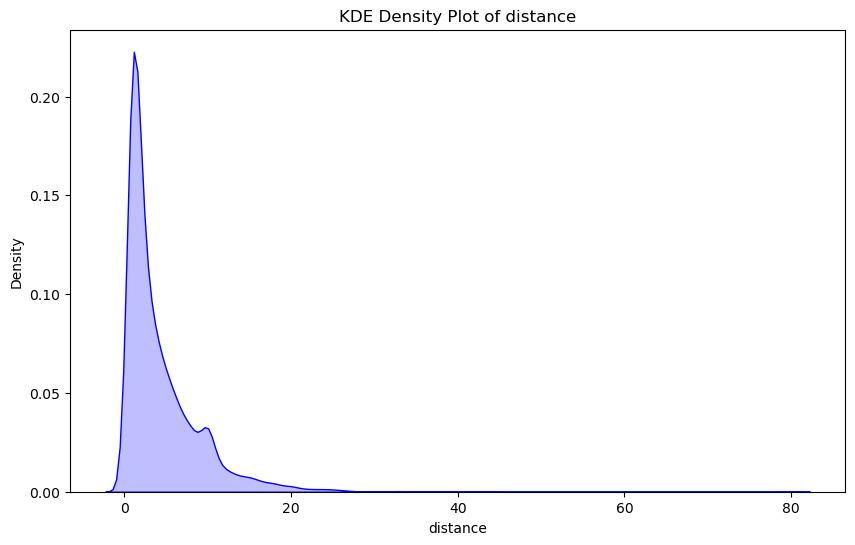

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(df.distance, fill=True, color='blue')
plt.title('KDE Density Plot of distance')
plt.xlabel('distance')
plt.ylabel('Density')
plt.show()

In [163]:
(
    df.query('100 >= yards_to_goal > 90').first_down.value_counts(normalize=True),
    df.query('90 >= yards_to_goal > 80').first_down.value_counts(normalize=True),
    df.query('80 >= yards_to_goal > 60').first_down.value_counts(normalize=True),
    df.query('60 >= yards_to_goal > 40').first_down.value_counts(normalize=True),
    df.query('40 >= yards_to_goal > 20').first_down.value_counts(normalize=True),
    df.query('20 >= yards_to_goal > 10').first_down.value_counts(normalize=True),
    df.query('10 >= yards_to_goal > 0').first_down.value_counts(normalize=True)
)

(first_down
 1    0.6
 0    0.4
 Name: proportion, dtype: float64,
 first_down
 0    0.721311
 1    0.278689
 Name: proportion, dtype: float64,
 first_down
 1    0.588571
 0    0.411429
 Name: proportion, dtype: float64,
 first_down
 1    0.577082
 0    0.422918
 Name: proportion, dtype: float64,
 first_down
 1    0.558148
 0    0.441852
 Name: proportion, dtype: float64,
 first_down
 1    0.580247
 0    0.419753
 Name: proportion, dtype: float64,
 first_down
 0    0.635081
 1    0.364919
 Name: proportion, dtype: float64)

## 5. Make the model

In [164]:
feature_names = [
    'distance',
    # 'score_diff',
    'diff_time_ratio',
    # 'pregame_elo_diff',
    # 'pct_game_played',
    'is_home_team',
    'precipitation', 
    'wind_speed', 
    'temperature', 
    'yards_to_goal', 
    # 'is_goal_to_go',
    'offense_pass_success_adjusted',
    'offense_rush_success_adjusted',
    'offense_strength', 
    'defense_strength'
]

data = df[['game_id','drive_id','play_id'] + feature_names + ['first_down']]

# Split into 80-20 train val set by game_id
game_ids = df.game_id.unique()
game_ids_train, game_ids_test = train_test_split(game_ids, test_size=0.2, random_state=42)

data_train = data[data.game_id.isin(game_ids_train)]
data_test = data[data.game_id.isin(game_ids_test)].drop(columns=['drive_id','play_id'])

In [165]:
data.shape

(7846, 15)

In [166]:
data.isna().sum()

game_id                          0
drive_id                         0
play_id                          0
distance                         0
diff_time_ratio                  0
is_home_team                     0
precipitation                    0
wind_speed                       0
temperature                      0
yards_to_goal                    0
offense_pass_success_adjusted    0
offense_rush_success_adjusted    0
offense_strength                 0
defense_strength                 0
first_down                       0
dtype: int64

In [167]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

# Set verbosity and random seed
optuna.logging.set_verbosity(optuna.logging.CRITICAL)
SEED = 2
np.random.seed(SEED)

# Prepare features and monotonic constraints
feature_names = data_train.drop(columns=['game_id','drive_id','play_id','first_down']).columns.tolist()
monotonic_constraints_map = {
    "score_diff": 1,
    "diff_time_ratio": 1,
    "pregame_elo_diff": 1,
    "is_home_team": 1,
    # "is_goal_to_go": -1, # Harder to convert in condensed space
    "precipitation": -1,
    "wind_speed": -1,
    "distance": -1,
    "offense_pass_success_adjusted": 1,
    "offense_rush_success_adjusted": 1,
    "offense_strength": 1,
    "defense_strength": -1,
}
monotonic_constraints = tuple([monotonic_constraints_map.get(feature, 0) for feature in feature_names])

# Only keep one play per drive
train_data = data_train.sample(frac=1, random_state=SEED).reset_index(drop=True)
train_data = train_data.drop_duplicates(subset=['game_id', 'drive_id'], keep='first')

# Split into train-val set by game_id
game_ids_train, game_ids_valid = train_test_split(
    train_data.game_id.unique(), 
    test_size=0.2, 
    random_state=SEED
)
train = train_data[train_data.game_id.isin(game_ids_train)]
valid = train_data[train_data.game_id.isin(game_ids_valid)]

# Prepare data for XGBoost
train_x = train.drop(columns=['game_id', 'drive_id', 'play_id', 'first_down'])
train_y = train['first_down']
valid_x = valid.drop(columns=['game_id', 'drive_id', 'play_id', 'first_down'])
valid_y = valid['first_down']

dtrain = xgb.DMatrix(train_x, label=train_y)
dvalid = xgb.DMatrix(valid_x, label=valid_y)

# Objective function for Optuna
def objective(trial):
    param = {
        "nthread": -1,
        "objective": "binary:logistic",
        "monotone_constraints": monotonic_constraints,
        "eval_metric": "logloss",
        "booster": "gbtree",
        "lambda": trial.suggest_float("lambda", 1e-5, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-5, 10.0, log=True),
        "eta": trial.suggest_float("eta", 0.05, 0.3, step=0.01),
        "max_depth": trial.suggest_int("max_depth", 3, 9, step=2),
        "min_child_weight": trial.suggest_float("min_child_weight", .5, 10, step=.5),
        "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "seed": SEED,
    }
    
    bst = xgb.train(
        param, 
        dtrain,
        num_boost_round=500,
        evals=[(dvalid, "eval")],
        early_stopping_rounds=10,
        verbose_eval=False
    )
    preds = bst.predict(dvalid)
    return log_loss(valid_y, preds)

# Run optimizatzion
study = optuna.create_study(
    study_name="conversion_probability_hyperopt", 
    direction="minimize", 
    load_if_exists=True
)
study.optimize(objective, n_trials=50)

# Train final model with best parameters
best_params = {
    **study.best_trial.params,
    'nthread': -1,
    'objective': 'binary:logistic',
    'booster': 'gbtree',
    'monotone_constraints': monotonic_constraints,
    'eval_metric': 'logloss',
    'seed': SEED,
}

final_model = xgb.train(
    best_params, 
    dtrain,
    num_boost_round=500,
    evals=[(dvalid, "eval")],
    early_stopping_rounds=10,
    verbose_eval=False
)

# train log loss
train_preds = final_model.predict(dtrain)
train_log_loss = log_loss(train_y, train_preds)
print(f'Train Log Loss: {train_log_loss:0.3f}')

# validation log loss
valid_preds = final_model.predict(dvalid)
valid_log_loss = log_loss(valid_y, valid_preds)
print(f'Validation Log Loss: {valid_log_loss:0.3f}')

# test log loss
test_x = data_test.drop(columns=['game_id', 'first_down'])
test_y = data_test['first_down']
dtest = xgb.DMatrix(test_x, label=test_y)
test_preds = final_model.predict(dtest)
test_log_loss = log_loss(test_y, test_preds)
print(f'Test Log Loss: {test_log_loss:0.3f}')

Train Log Loss: 0.600
Validation Log Loss: 0.617
Test Log Loss: 0.607


1. all features
Train Log Loss: 0.605
Validation Log Loss: 0.614
Test Log Loss: 0.623

2. without pregame elo diff and pct game played
Train Log Loss: 0.610
Validation Log Loss: 0.615
Test Log Loss: 0.625

3. same as 2 but with diff_time_ration instead of score_diff
Train Log Loss: 0.609
Validation Log Loss: 0.616
Test Log Loss: 0.624


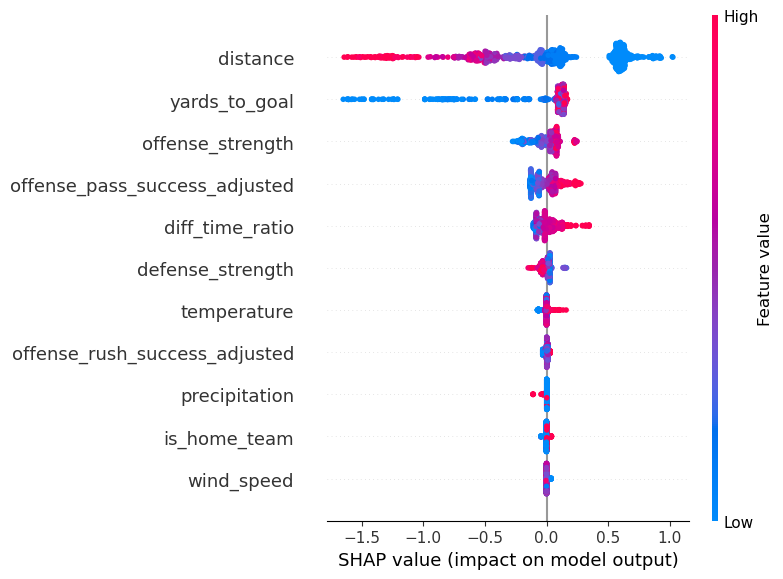

In [168]:
import shap
background = train[feature_names].head(1000)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(background)
shap.summary_plot(shap_values, 
                 background, 
                 plot_type="dot",  # "dot" (default), "bar", or "violin"
                 max_display=15,
                 show=True)

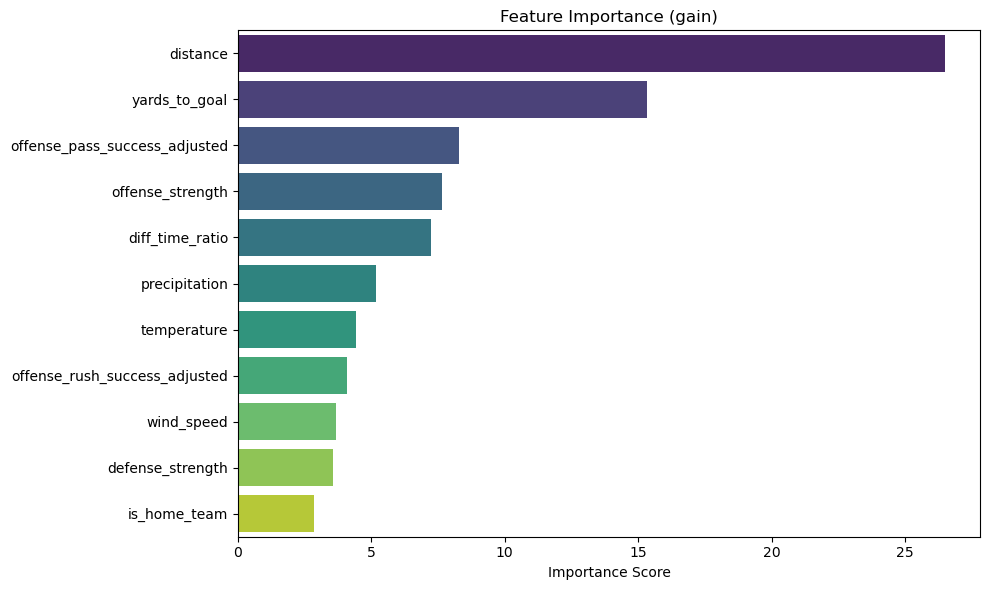

In [169]:
importance_type = "gain"  # Options: "gain", "weight", "cover"

# Get feature importance for a single model
importance = final_model.get_score(importance_type=importance_type)

# Convert to DataFrame and sort
importance_df = pd.DataFrame({
    "Feature": list(importance.keys()),
    "Importance": list(importance.values())
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=importance_df, 
    palette="viridis", 
    hue="Feature", 
    dodge=False
)
plt.title(f"Feature Importance ({importance_type})")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

In [170]:
importance_df

,Feature,Importance
0,distance,26.486446
6,yards_to_goal,15.326075
7,offense_pass_success_adjusted,8.291571
9,offense_strength,7.642744
1,diff_time_ratio,7.242747
3,precipitation,5.186413
5,temperature,4.411186
8,offense_rush_success_adjusted,4.069579
4,wind_speed,3.660157
10,defense_strength,3.554225


In [171]:
# predict conversion_proba for all plays
df['conversion_proba'] = final_model.predict(xgb.DMatrix(df[feature_names]))

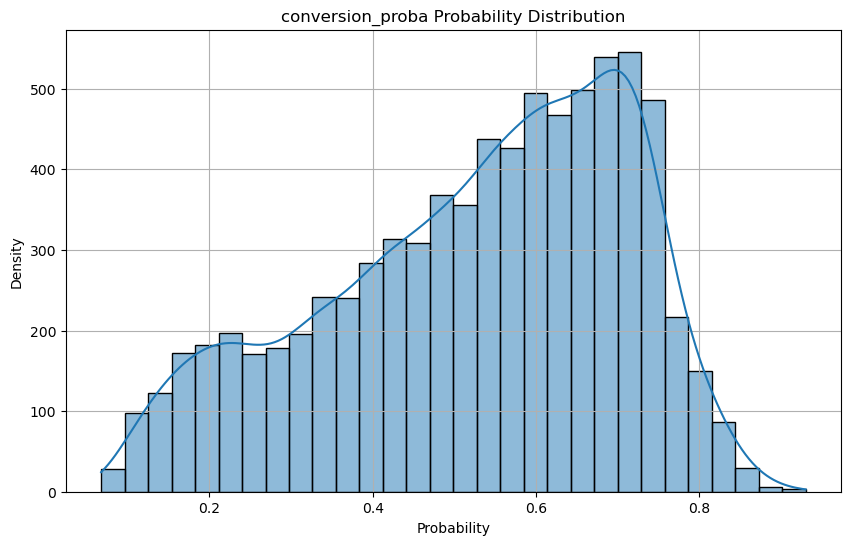

In [172]:
# plot win probability
def plot_wp(df, col='conversion_proba'):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'{col} Probability Distribution')
    plt.xlabel('Probability')
    plt.ylabel('Density')
    plt.grid()
    plt.show()
plot_wp(df, col='conversion_proba')

Brier Score: 0.2080


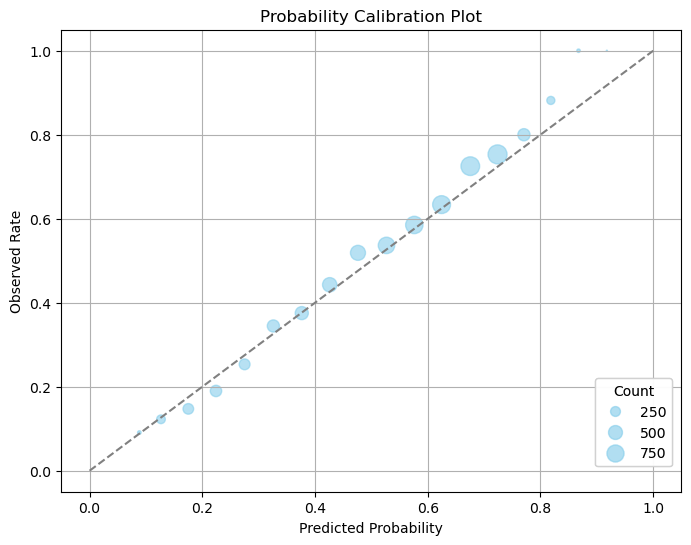

In [173]:
calibration = pd.DataFrame()
def plot_calibration(df, proba_col, actual_col, bins=100, scale=0.02):
    global calibration
    df['proba_bin'] = pd.cut(df[proba_col], bins=np.linspace(0, 1, bins + 1), labels=False, include_lowest=True)
    calibration = df.groupby('proba_bin').agg(
        predicted_proba=(proba_col, 'mean'),
        actual_proba=(actual_col, 'mean'),
        count=(proba_col, 'size')
    ).reset_index()

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        calibration['predicted_proba'], 
        calibration['actual_proba'], 
        s=calibration['count'] * scale,
        alpha=0.6, 
        label='Calibration Curve',
        color='skyblue',
    )
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Rate')
    plt.title('Probability Calibration Plot')
    plt.grid()

    # Add legend for dot size reference
    handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=4, func=lambda x: x / scale,
                                              color='skyblue')
    labels = [int(re.search(r'\{(\d+)\}', value).group(1)) for value in labels]
    legend = plt.legend(handles, labels, title="Count", loc="center left", bbox_to_anchor=(.85, 0.15))
    plt.gca().add_artist(legend)

    plt.show()

# brier score
from sklearn.metrics import brier_score_loss
brier_score = brier_score_loss(df['first_down'], df['conversion_proba'])
print(f'Brier Score: {brier_score:.4f}')
plot_calibration(df, proba_col='conversion_proba', actual_col='first_down', bins=20, scale=.2)

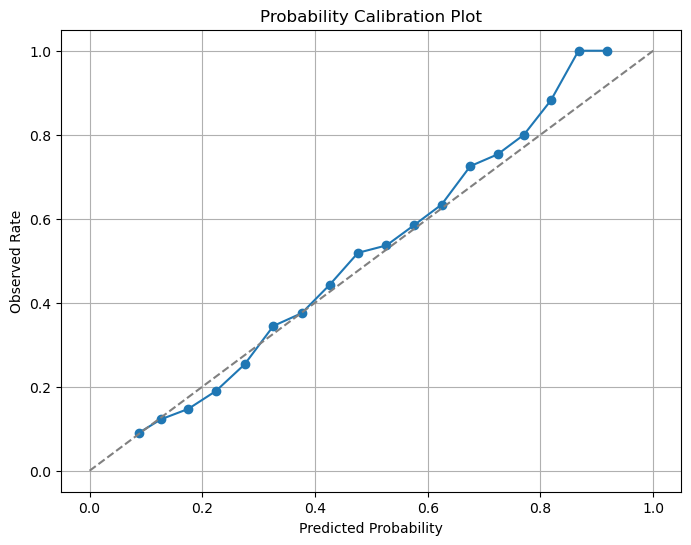

In [174]:
calibration = pd.DataFrame()
def plot_calibration(df, proba_col, actual_col, bins=100, scale=0.2):
    global calibration
    df['proba_bin'] = pd.cut(df[proba_col], bins=np.linspace(0, 1, bins + 1), labels=False, include_lowest=True)
    calibration = df.groupby('proba_bin').agg(
        predicted_proba=(proba_col, 'mean'),
        actual_proba=(actual_col, 'mean'),
        count=(proba_col, 'size')
    ).reset_index()

    plt.figure(figsize=(8, 6))
    plt.plot(calibration['predicted_proba'], calibration['actual_proba'], label='Calibration Curve', marker='o')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Rate')
    plt.title('Probability Calibration Plot')
    plt.grid()
    plt.show()

plot_calibration(df, proba_col='conversion_proba', actual_col='first_down', bins=20)

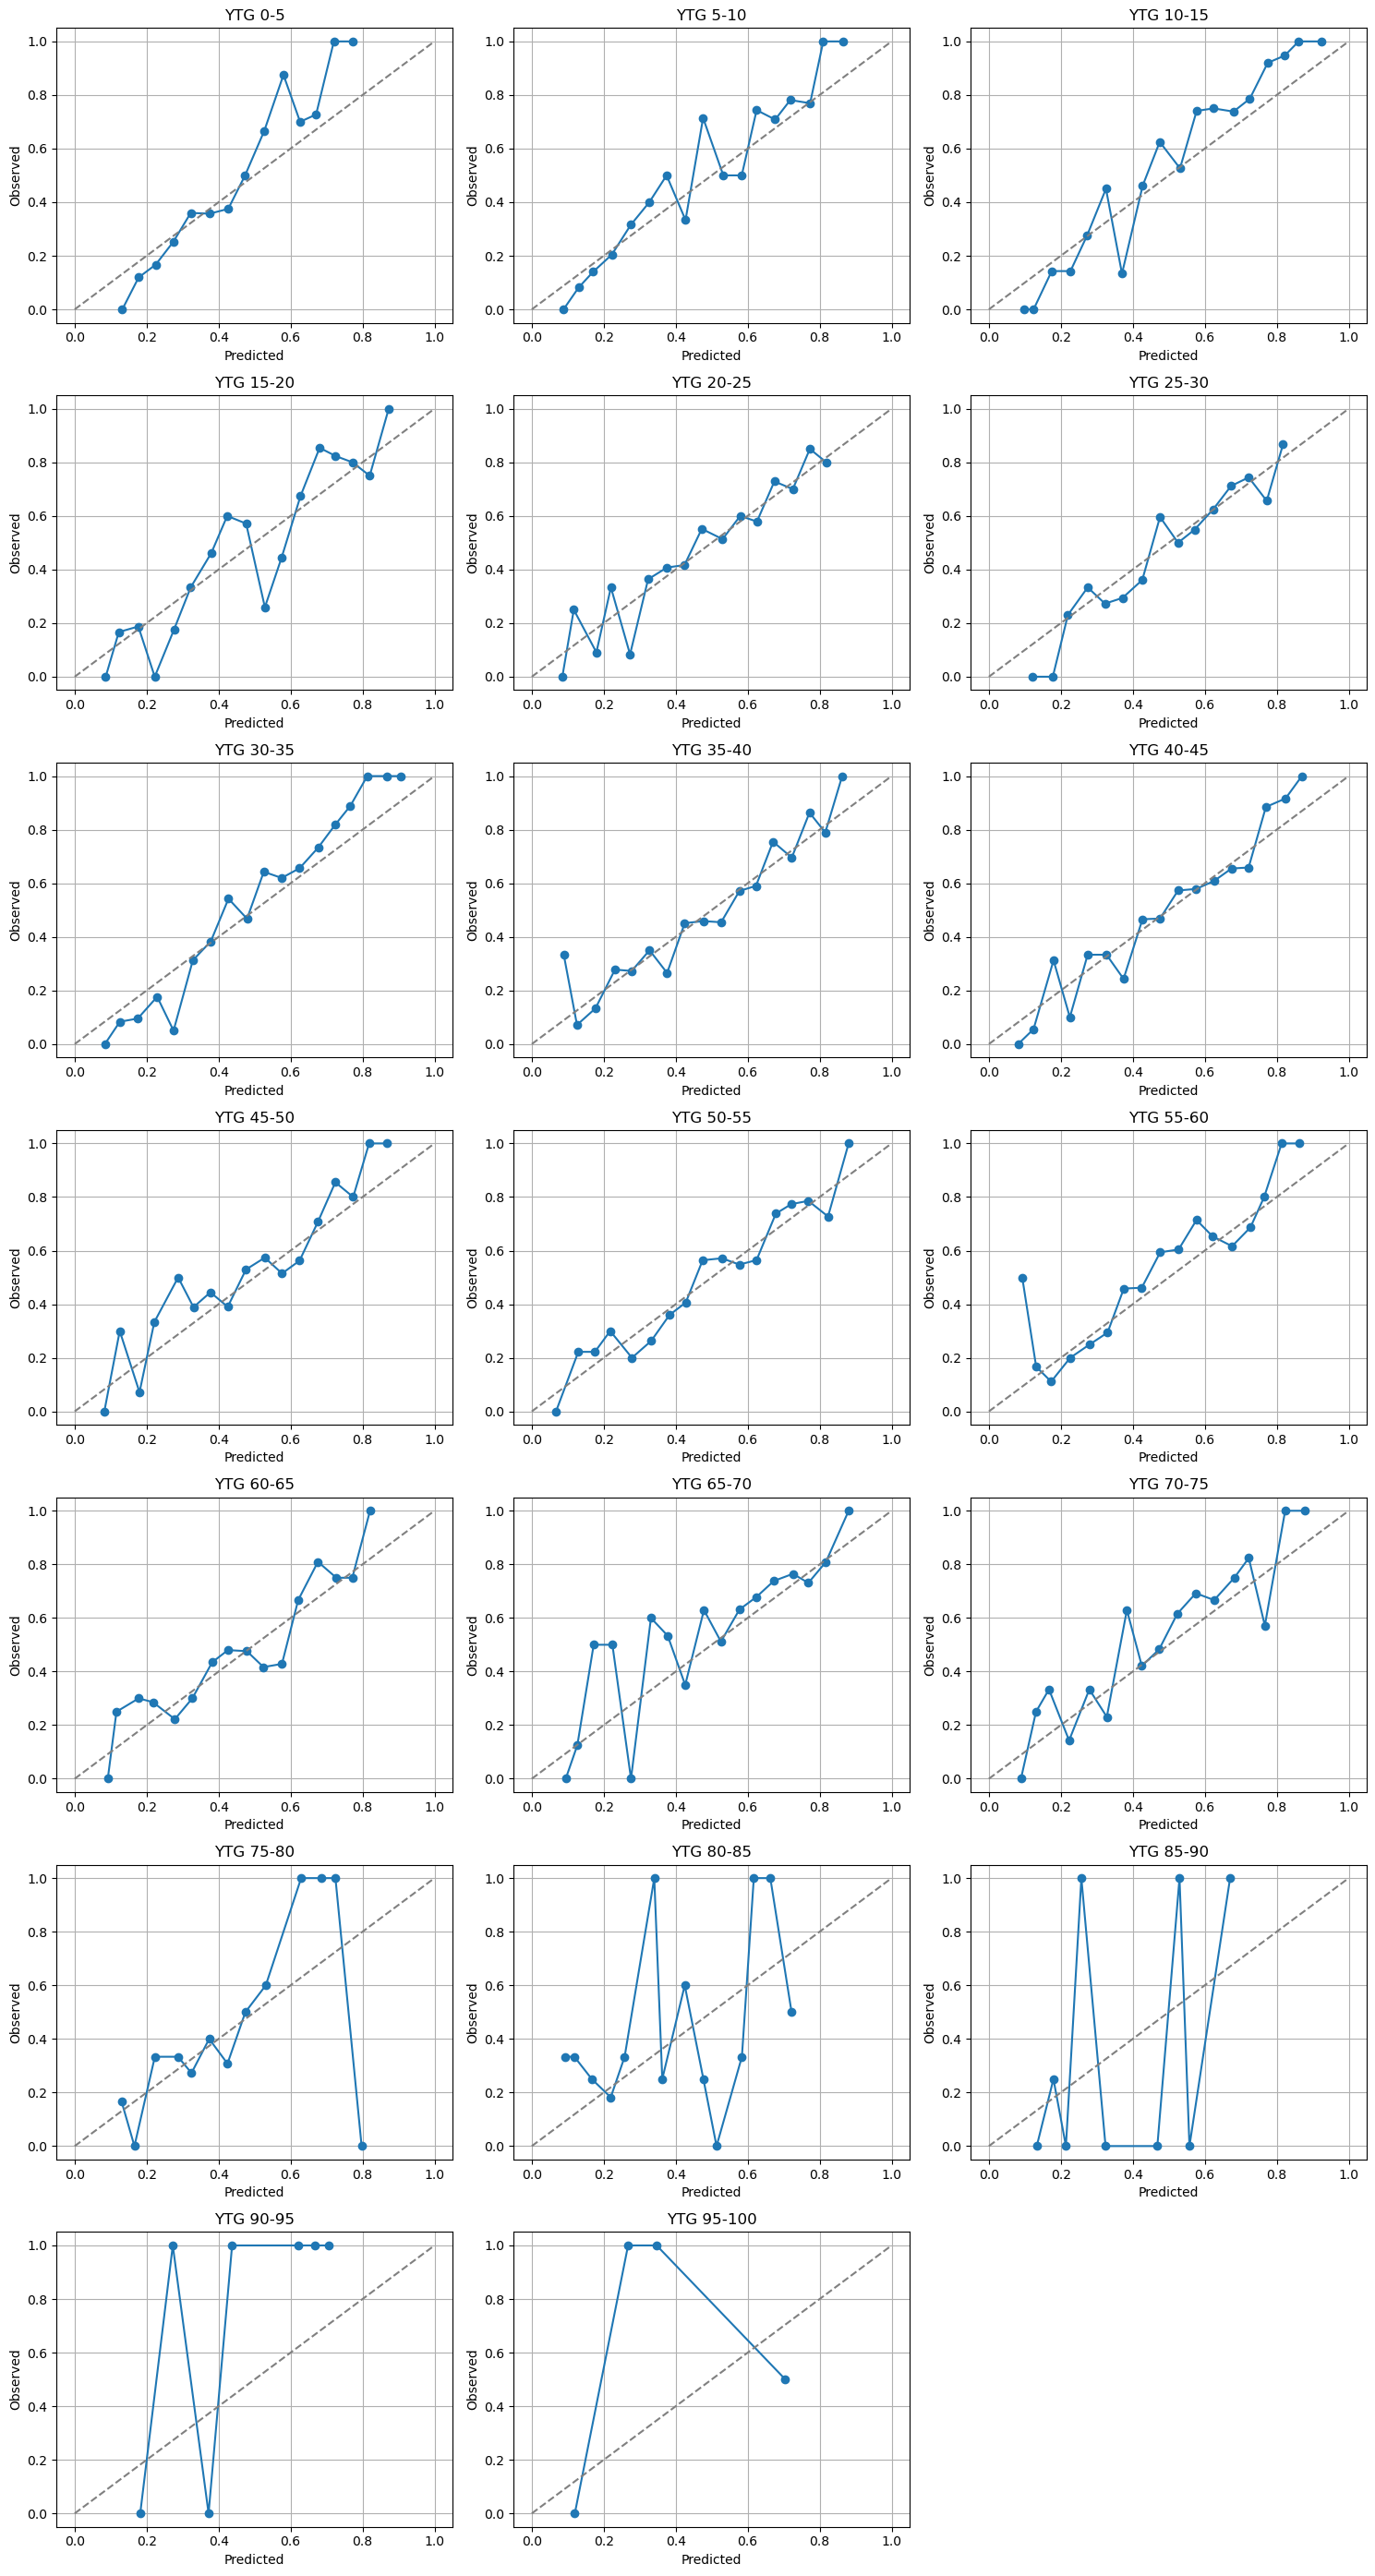

In [175]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

def get_calibration(df, proba_col, actual_col, bins=20):
    df = df.copy()
    df['proba_bin'] = pd.cut(
        df[proba_col],
        bins=np.linspace(0, 1, bins + 1),
        labels=False,
        include_lowest=True
    )

    calibration = df.groupby('proba_bin').agg(
        predicted_proba=(proba_col, 'mean'),
        actual_proba=(actual_col, 'mean'),
        count=(proba_col, 'size')
    ).reset_index()

    return calibration


# YTG bins
ytg_ranges = [(i, i+5) for i in range(0, 100, 5)]

cols = 3
rows = math.ceil(len(ytg_ranges) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
axes = axes.flatten()

for idx, (i, i_plus) in enumerate(ytg_ranges):
    ax = axes[idx]
    
    subset = df.query('@i <= yards_to_goal and yards_to_goal < @i_plus')
    
    if len(subset) == 0:
        ax.axis("off")
        continue

    calibration = get_calibration(
        subset,
        proba_col='conversion_proba',
        actual_col='first_down',
        bins=20
    )

    ax.plot(calibration['predicted_proba'], calibration['actual_proba'], marker='o')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(f'YTG {i}-{i_plus}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Observed')
    ax.grid(True)

# Turn off any extra empty subplots
for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [176]:
df[df['yards_to_goal'] == 2].query('yards_to_goal != distance').distance.describe()

count    8.000000
mean     0.875000
std      0.353553
min      0.000000
25%      1.000000
50%      1.000000
75%      1.000000
max      1.000000
Name: distance, dtype: float64

In [177]:
df[df['yards_to_goal'] <= 10].shape[0]

994

In [225]:
explainer = shap.TreeExplainer(
    final_model,
    data=train_x.sample(3000, random_state=SEED),
    model_output="probability",
    feature_perturbation="interventional"
)

In [230]:
df.query('distance >= 5 and offense_pass_success_adjusted < 0.3 and offense_rush_success_adjusted > 0.4 and season==2017').head()

,game_id,drive_id,play_id,drive_number,play_number,season,week,season_type,offense,defense,offense_timeouts,defense_timeouts,yards_to_goal,down,distance,yards_gained,is_goal_to_go,play_type,play_text,game_indoors,temperature,precipitation,wind_speed,pct_game_played,score_diff,is_home_team,pregame_elo_diff,pregame_offense_elo,pregame_defense_elo,offense_strength,defense_strength,diff_time_ratio,offense_pass_success_adjusted,offense_rush_success_adjusted,first_down
2532,400938658,40093865822,400938658104944016,20,14,2017,11,regular,UTEP,North Texas,3.0,3.0,16,4,10,6,0,Rush,Mark Torrez run for 6 yds to the NoTex 10,False,66.9,0.0,18.3,0.900278,-35,-1,-485.718662,972.488308,1458.206971,-0.223980,-0.026459,-1282.362261,0.298109,0.402109,0
2590,400934571,4009345714,400934571101988902,4,9,2017,12,regular,Army,North Texas,2.0,3.0,36,4,11,0,0,Pass Incompletion,Ahmad Bradshaw pass incomplete,False,57.0,0.0,19.7,0.230556,-7,-1,441.961522,1928.178087,1486.216564,0.088801,-0.033822,-17.604110,0.293927,0.490943,0


In [228]:
explainer = shap.TreeExplainer(
    final_model,
    data=train_x.sample(3000, random_state=SEED),
    model_output="probability",
    feature_perturbation="interventional"
)

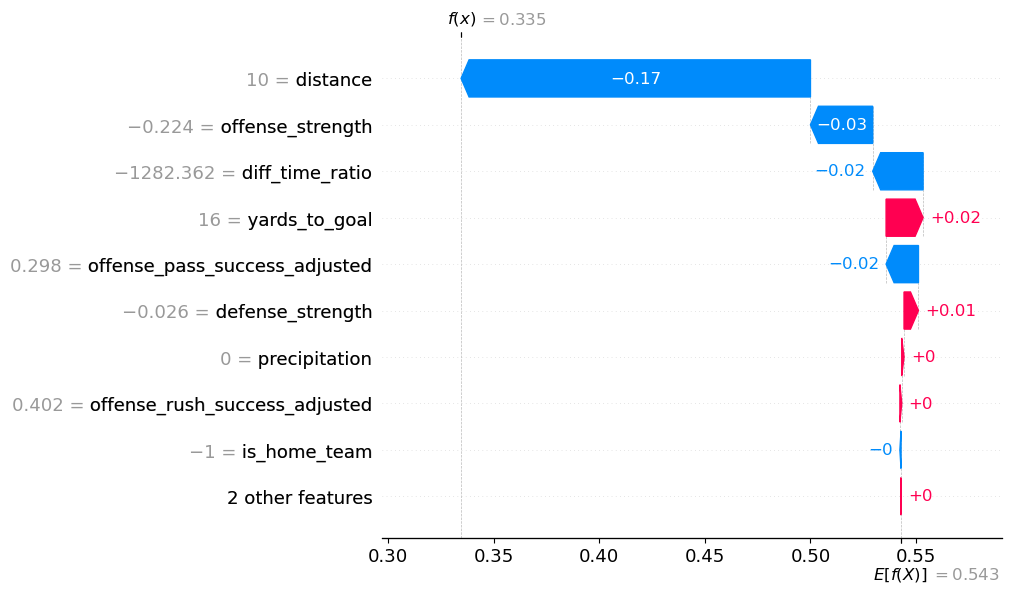

In [231]:
game_data = data.loc[(data.play_id=="400938658104944016"), feature_names].head(1)
shap_values = explainer.shap_values(game_data)
shap_values = explainer.shap_values(game_data)
shap_values_explained = shap.Explanation(values=shap_values, 
                                         base_values=explainer.expected_value, 
                                         data=game_data, 
                                         feature_names=game_data.columns)

shap.plots.waterfall(shap_values_explained[0])
plt.show()

In [232]:
model_dir = join('..', 'models', 'fourth_down')
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, f"xgb_classifier.json")
final_model.save_model(model_path)

print(f"Saved model to the '{model_dir}' folder.")

Saved model to the '../models/fourth_down' folder.


In [233]:
# load the model
model_dir = join('..', 'models', 'fourth_down')
model_path = os.path.join(model_dir, f"xgb_classifier.json")
model = xgb.Booster()
model.load_model(model_path)
print(f"Loaded model from '{model_path}'")

Loaded model from '../models/fourth_down/xgb_classifier.json'


In [235]:
df.query('distance==0').shape

(20, 35)

In [236]:
df.query('distance==1').shape

(2754, 35)

In [237]:
df.head()

,game_id,drive_id,play_id,drive_number,play_number,season,week,season_type,offense,defense,offense_timeouts,defense_timeouts,yards_to_goal,down,distance,yards_gained,is_goal_to_go,play_type,play_text,game_indoors,temperature,precipitation,wind_speed,pct_game_played,score_diff,is_home_team,pregame_elo_diff,pregame_offense_elo,pregame_defense_elo,offense_strength,defense_strength,diff_time_ratio,offense_pass_success_adjusted,offense_rush_success_adjusted,first_down
0,332412579,33241257920,332412579224,20,15,2013,1,regular,North Carolina,South Carolina,1.0,3.0,8,4,8,7,1,Rush,Bryn Renner rush for 7 yards to the SCaro 1.,False,93.9,0.0,0.0,0.983889,-17,-1,-559.687637,2473.956961,3033.644599,0.144564,0.086804,-870.239882,0.440701,0.452601,0
1,332430194,33243019421,332430194239,21,7,2013,1,regular,Buffalo,Ohio State,3.0,3.0,54,4,1,7,0,Rush,Branden Oliver rush for 7 yards to the OhSt 47...,False,82.9,0.0,8.1,0.736389,-17,-1,-1760.247194,1259.238028,3019.485222,-0.095033,0.129266,-323.360856,0.376980,0.398600,1
2,332430194,33243019421,332430194253,21,16,2013,1,regular,Buffalo,Ohio State,2.0,3.0,2,4,2,0,1,Rush,Joe Licata rush for no gain to the OhSt 2.,False,82.9,0.0,8.1,0.795000,-17,-1,-1760.247194,1259.238028,3019.485222,-0.095033,0.129266,-408.794810,0.376980,0.398600,0
3,332432132,33243213203,332432132025,3,11,2013,1,regular,Purdue,Cincinnati,3.0,3.0,7,4,1,2,0,Rush,Rob Henry rush for 2 yards to the Cincy 5 for ...,False,82.0,0.0,7.0,0.117222,0,-1,-468.624582,2048.434152,2517.058734,-0.048378,0.000332,0.000000,0.418379,0.433684,1
4,332432572,33243257232,332432572184,31,4,2013,1,regular,Texas State,Southern Miss,3.0,2.0,84,4,19,19,0,Pass Completion,Tyler Arndt deep in pass complete to Andy Eric...,False,90.9,0.0,4.7,0.904722,-1,-1,-186.089641,1341.235179,1527.324821,0.007203,-0.036081,-37.296105,0.381281,0.402246,1


In [238]:
df.query('distance == 0').first_down.value_counts(normalize=True)

first_down
1    0.6
0    0.4
Name: proportion, dtype: float64

In [241]:
qry = df.query('distance == 0')

print(qry.shape[0])
qry.first_down.value_counts(normalize=True)

20


first_down
1    0.6
0    0.4
Name: proportion, dtype: float64

In [240]:
qry = df.query('distance == 1')

print(qry.shape[0])
qry.first_down.value_counts(normalize=True)

2754


first_down
1    0.706972
0    0.293028
Name: proportion, dtype: float64

In [242]:
qry = df.query('distance == 1 and yards_to_goal <= 10')

print(qry.shape[0])
qry.first_down.value_counts(normalize=True)

461


first_down
0    0.503254
1    0.496746
Name: proportion, dtype: float64

In [ ]:
qry = df.query('distance == 1 and yards_to_goal <= 10')

print(qry.shape[0])
qry.first_down.value_counts(normalize=True)

313


first_down
0    0.623003
1    0.376997
Name: proportion, dtype: float64

In [249]:
qry = df.query('distance == 1 and yards_to_goal == 2')

print(qry.shape[0])
qry.first_down.value_counts(normalize=True)

7


first_down
1    0.571429
0    0.428571
Name: proportion, dtype: float64

In [250]:
qry = df.query('distance == 1 and yards_to_goal <= 1')

print(qry.shape[0])
qry.first_down.value_counts(normalize=True)

241


first_down
0    0.73444
1    0.26556
Name: proportion, dtype: float64

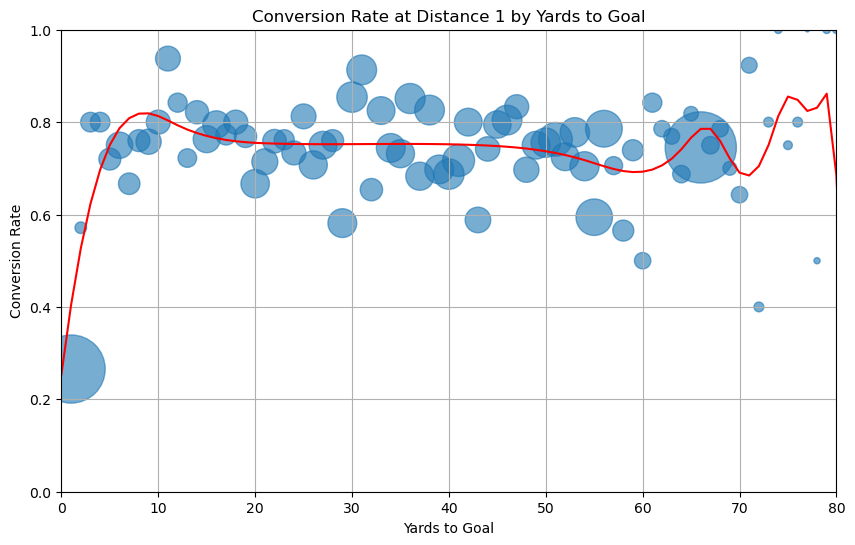

In [259]:
y_spline

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan])